In [ ]:
import matplotlib.pyplot as plt
import torch 
import numpy as np
import pembhb
from pembhb import ROOT_DIR
from pembhb.rom import ReducedOrderModel
import importlib
importlib.reload(pembhb)
import os 

# # wide parameter space
# rom_filename =  os.path.join(ROOT_DIR, "rom_20260108_v2_centered.pt")
# data_filename = "/data/gpuleo/mbhb/20260108_v1/simulation_round_2.h5"

## narrow parameter space
# rom_filename =  os.path.join(ROOT_DIR, "debug_rom_narrow_ok_centered_mgs_vnonstop.pt")
# data_filename = "/data/gpuleo/mbhb/narrow_prior.h5"

### narrow parameter space, training
# rom_filename =  "/data/gpuleo/mbhb/20260122_narrowprior_v1/rom_round_0.pt"
# data_filename = "/data/gpuleo/mbhb/20260122_narrowprior_v1/simulation_round_0.h5"

# ## nre run with reorthogonalised rom and low noise. 
# data_filename = "/data/gpuleo/mbhb/20260123_narrowprior_v1/simulation_round_0.h5"
# rom_filename = "/data/gpuleo/mbhb/20260123_narrowprior_v1/rom_round_0.pt"


# data_filename = "/data/gpuleo/mbhb/20260202_narrowprior_v1/simulation_round_0.h5"
# rom_filename = os.path.join(ROOT_DIR, "debug_rom_with_denoisingerror.pt")

# data_filename = "/data/gpuleo/mbhb/20260204_narrowprior_v2/simulation_round_0.h5"
# rom_filename = "/data/gpuleo/mbhb/20260204_narrowprior_v2/rom_round_0.pt"


#data_filename = "/data/gpuleo/mbhb/20260211fullsky_v0/simulation_round_1.h5"
#rom_filename = os.path.join(ROOT_DIR, "rom_sigmadata_fixed.pt")
rom_filename = os.path.join(ROOT_DIR, "rom_noiseweight_sky_tc_mass.pt")
#rom_filename =  "/data/gpuleo/mbhb/20260211fullsky_v0/rom_round_1.pt"

data_filename = "/data/gpuleo/mbhb/20260213autoenc_fullsky_narrowmc_tc_v0/simulation_round_1.h5"
data_filename = "/data/gpuleo/mbhb/20260204_narrowprior_v1/simulation_round_0.h5" # narrow round
#rom_filename = os.path.join(ROOT_DIR, "rom_narrow_debug_both_domains.pt")
rom_basename = os.path.basename(rom_filename).removesuffix('.pt')
plot_dir = os.path.join(ROOT_DIR, "plots", f"diagnose_rom_{rom_basename}")
os.makedirs(plot_dir, exist_ok=True)
diagnostics_filename = rom_filename.removesuffix('.pt') + '_diagnostics.pt'


ROOT_DIR: /u/g/gpuleo/pembhb
ROOT_DIR: /u/g/gpuleo/pembhb


In [2]:
rom = ReducedOrderModel(filename=rom_filename)
rom.load_diagnostics(filename=diagnostics_filename)

# Helper to resolve the diagnostics dict.
# New format: rom.training_diagnostics["diagnostics"] or ["diagnostics_fd"]/["diagnostics_td"]
# Old format: rom.training_diagnostics contains the keys directly.
def get_domain_diagnostics(rom, dom='fd'):
    """Return the diagnostics dict for a given domain, handling old and new formats."""
    td = rom.training_diagnostics
    # New format (single domain, stored under "diagnostics")
    if "diagnostics" in td:
        return td["diagnostics"]
    # New format (both domains)
    if f"diagnostics_{dom}" in td:
        return td[f"diagnostics_{dom}"]
    # Old format: keys are at top level
    return td

# Choose which domain to visualise (change to 'td' if inspecting a td ROM)
VIS_DOMAIN = 'fd'
train_diagnostics = get_domain_diagnostics(rom, VIS_DOMAIN)

log10mc_values = train_diagnostics["log10mc_values"]
q_values = train_diagnostics["q_values"]
sigmas = train_diagnostics["sigmas"]
sigmas_unnorm = train_diagnostics["sigmas_unnorm"]
sigmas_data = train_diagnostics["sigmas_data"]
rounds = np.arange(1, len(sigmas) + 1)
log10mc_arr = np.array([float(x) for x in log10mc_values])
q_arr = np.array([float(x) for x in q_values])
sig_arr = np.array([float(x) for x in sigmas])
sig_unnorm_arr = np.array([float(x) for x in sigmas_unnorm])

print(f"ROM domain: {rom.domain}")
print(f"Visualising domain: {VIS_DOMAIN}")
print(f"Active domains: {rom._active_domains}")
for dom in rom._active_domains:
    basis = getattr(rom, f'basis_{dom}', None)
    if basis is not None:
        print(f"  {dom}: basis shape = {basis.shape}")

[ROM] initializing from file /u/g/gpuleo/pembhb/rom_noiseweight_df_scaled_fixedbug.pt.
 Other arguments will be ignored.
Keys in the saved file: ['domain', 'tolerance', 'device', 'freq_cutoff_idx', 'df', 'dt', 'asd', 'basis_fd', 'n_channels_fd', 'n_dim_fd', 'global_scale_factor_fd', 'mean_vec_fd', 'valid_bins_mask_fd', 'inner_weights_fd', 'basis', 'n_channels', 'n_freq', 'global_scale_factor', 'mean_vec']
name of the saved file: /u/g/gpuleo/pembhb/rom_noiseweight_df_scaled_fixedbug.pt
[ROM] ASD loaded, shape=(2, 4096)
[ROM] fd valid_bins_mask loaded: 8192/8192 bins active
[ROM] fd inner_weights loaded (min=4.8828e-06, max=4.8828e-06)
[ROM] fd basis loaded. n_dim=4096, n_channels=2, n_basis=11
ROM domain: fd
Visualising domain: fd
Active domains: ['fd']
  fd: basis shape = torch.Size([11, 8192])


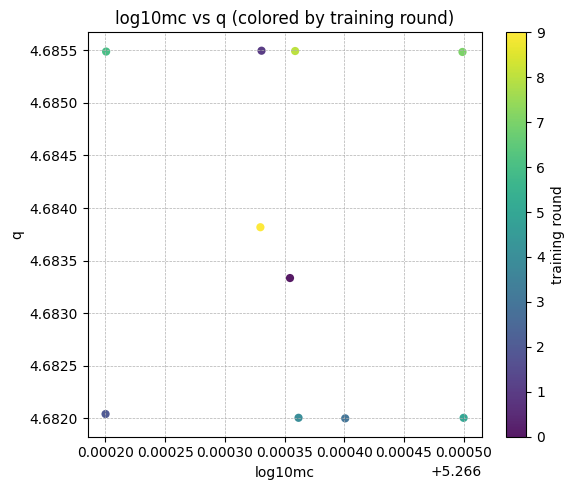

In [3]:
# 1) sigmas and sigmas_unnorm vs training round
plt.figure(figsize=(8, 5))
plt.plot(rounds, sig_arr, marker='o', label='sigma (normalized)')
plt.plot(rounds, sig_unnorm_arr, marker='x', label='sigma (unnormalized)')
plt.xlabel('Training round')
plt.ylabel('Residual (sigma)')
plt.yscale('log')
plt.title('ROM residuals during greedy training')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('rom_sigmas_vs_round.png', dpi=150)
plt.close()
# 2) scatter of log10mc_values vs q_values colored by sigmas
plt.figure(figsize=(6, 5))

idx = np.arange(log10mc_arr.shape[0])
norm = plt.Normalize(vmin=idx.min(), vmax=idx.max())
cmap = 'viridis'
# remaining points, marker 'o'
sc2 = plt.scatter(
    log10mc_arr,
    q_arr,
    c=idx,
    cmap=cmap,
    norm=norm,
    s=35,
    marker='o',
    edgecolors='none',
    alpha=0.9,
)

cbar = plt.colorbar(sc2)
cbar.set_label('training round')
plt.xlabel('log10mc')
plt.ylabel('q')
plt.title('log10mc vs q (colored by training round)')
plt.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'rom_log10mc_q_colored_by_training_round.png'), dpi=150)
plt.show()
plt.close()

In [4]:
basis = getattr(rom, f'basis_{VIS_DOMAIN}')
print(f"basis_{VIS_DOMAIN} shape: {basis.shape}")

basis_fd shape: torch.Size([11, 8192])


In [5]:
full_basis = getattr(rom, f'basis_{VIS_DOMAIN}').clone()

In [6]:
rom.basis_fd = full_basis[:3]

In [7]:
getattr(rom, f'basis_{VIS_DOMAIN}').shape

torch.Size([3, 8192])

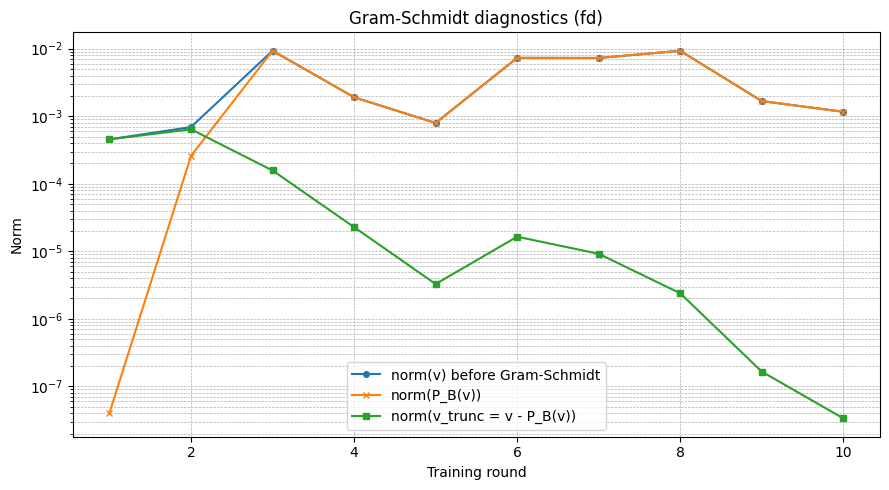

In [8]:
# 3) diagnose Gram-Schmidt norms
gs_diagnose = train_diagnostics["gs_diagnose"]
norm_original = np.array(gs_diagnose["norm_v_original"], dtype=float)
norm_proj = np.array(gs_diagnose["norm_projection"], dtype=float)
norm_v_trunc = np.array(gs_diagnose["norm_v_trunc"], dtype=float)
rounds_o = np.arange(1, len(norm_original) + 1)
rounds_p = np.arange(1, len(norm_proj) + 1)
rounds_t = np.arange(1, len(norm_v_trunc) + 1)

plt.figure(figsize=(9, 5))
ax = plt.gca()
ax.plot(rounds_o, norm_original, marker='o', linestyle='-', markersize=4, label='norm(v) before Gram-Schmidt')
ax.plot(rounds_p, norm_proj,    marker='x', linestyle='-', markersize=4, label='norm(P_B(v))')
ax.plot(rounds_t, norm_v_trunc, marker='s', linestyle='-', markersize=4, label='norm(v_trunc = v - P_B(v))')

ax.set_xlabel('Training round')
ax.set_ylabel('Norm')
ax.set_yscale('log')
ax.set_title(f'Gram-Schmidt diagnostics ({VIS_DOMAIN})')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'gs_norms_combined_{VIS_DOMAIN}.png'), dpi=150)
plt.show()
plt.close()

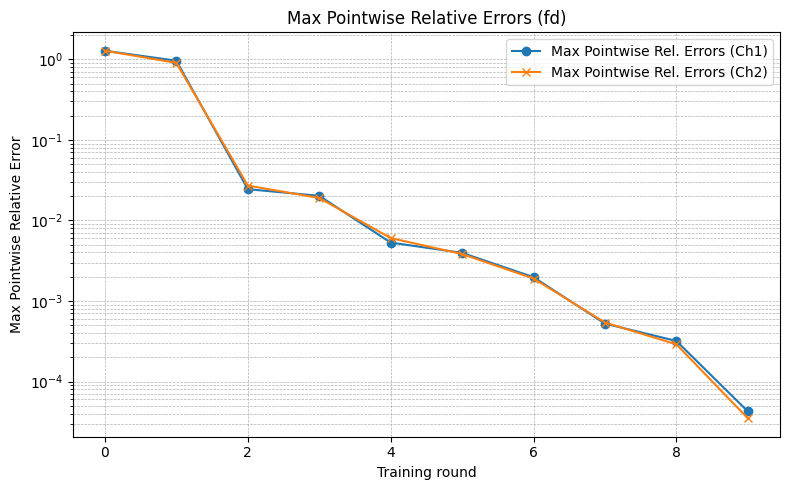

In [9]:
# Max pointwise relative errors per channel
# New format uses "max_pointwise_relerrors_ch1/ch2"; old format uses "_real/_imag"
if "max_pointwise_relerrors_ch1" in train_diagnostics:
    max_relerr_ch1 = train_diagnostics["max_pointwise_relerrors_ch1"]
    max_relerr_ch2 = train_diagnostics["max_pointwise_relerrors_ch2"]
    label1, label2 = f'Max Pointwise Rel. Errors (Ch1)', f'Max Pointwise Rel. Errors (Ch2)'
else:
    max_relerr_ch1 = train_diagnostics["max_pointwise_relerrors_real"]
    max_relerr_ch2 = train_diagnostics["max_pointwise_relerrors_imag"]
    label1, label2 = 'Max Pointwise Rel. Errors (Real)', 'Max Pointwise Rel. Errors (Imag)'

plt.figure(figsize=(8, 5))
plt.plot(max_relerr_ch1, label=label1, marker='o')
plt.plot(max_relerr_ch2, label=label2, marker='x')
plt.yscale('log')
plt.xlabel('Training round')
plt.ylabel('Max Pointwise Relative Error')
plt.title(f'Max Pointwise Relative Errors ({VIS_DOMAIN})')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
max_relerr_ch1

[1.2783771753311157,
 0.9614953398704529,
 0.024434085935354233,
 0.020214732736349106,
 0.0053138043731451035,
 0.003954960033297539,
 0.0019765228498727083,
 0.0005236159777268767,
 0.00031879558810032904,
 4.25424259447027e-05]

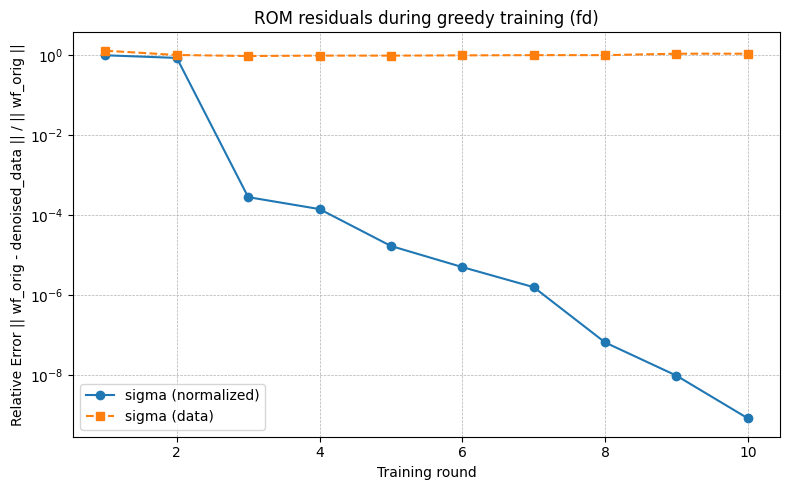

In [11]:
sigmas = train_diagnostics["sigmas"]
sigmas_unnorm = train_diagnostics["sigmas_unnorm"]
sigmas_data = train_diagnostics["sigmas_data"]

plt.figure(figsize=(8, 5))
plt.plot(rounds, sigmas, marker='o', label='sigma (normalized)')
#plt.plot(rounds, sigmas_unnorm, marker='x', label='sigma (unnormalized)')
plt.plot(rounds, sigmas_data, marker='s', label='sigma (data)', linestyle='--')
plt.xlabel('Training round')
plt.ylabel('Relative Error || wf_orig - denoised_data || / || wf_orig ||')
plt.yscale('log')
#plt.xlim(900,950)
#plt.ylim(8e-1-4e-2, 8e-1+1e-2)
#plt.xscale("log")
plt.title(f'ROM residuals during greedy training ({VIS_DOMAIN})')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'rom_sigmas_vs_round_{VIS_DOMAIN}.png'), dpi=150)

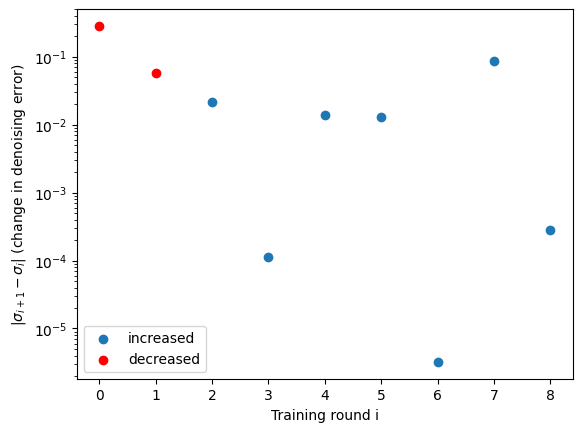

In [12]:
sigmas_data_arr = np.array([float(x) for x in sigmas_data])
increased = (np.diff(sigmas_data_arr) >0)
plt.figure()
plt.scatter(np.argwhere(increased), np.diff(sigmas_data_arr)[increased], label="increased")
plt.scatter(np.argwhere(~increased), -np.diff(sigmas_data_arr)[~increased], color="red", label="decreased")
plt.xlabel('Training round i')
plt.ylabel(r'$|\sigma_{i+1} - \sigma_{i}|$ (change in denoising error)')
plt.legend()
plt.yscale("log")



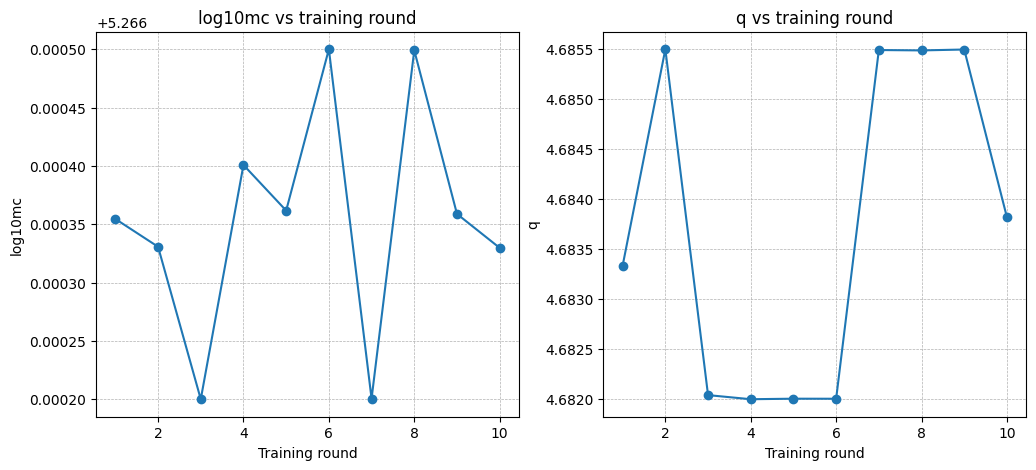

In [13]:
### plot also the q value and the chirp mass value vs training round for both roms: 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rounds, log10mc_arr, marker='o', label='New ROM')
#plt.plot(round_old, log10mc_values_old, marker='x', label='Old ROM')
plt.xlabel('Training round')
plt.ylabel('log10mc')
plt.title('log10mc vs training round')
plt.grid(True, ls='--', lw=0.5)
plt.subplot(1, 2, 2)
plt.plot(rounds, q_arr, marker='o', label='New ROM')
#plt.plot(round_old, q_values_old, marker='x', label='Old ROM')
plt.xlabel('Training round')
plt.ylabel('q')
plt.title('q vs training round')
plt.grid(True, ls='--', lw=0.5)
plt.savefig(os.path.join(plot_dir, 'rom_log10mc_q_vs_training_round.png'), dpi=150)
plt.show()
plt.close()


In [14]:
rom._inner

<bound method ReducedOrderModel._inner of <pembhb.rom.ReducedOrderModel object at 0x7f7fb17aa900>>

In [15]:
from pembhb.utils import fd_inner

Gram matrix for domain 'fd', shape: (3, 3)
abs stats -> min: 0.000e+00, max: 1.000e+00, mean: 3.333e-01, std: 4.714e-01
real part stats -> min: -1.490e-08, max: 1.000e+00
imag part stats -> min: 0.000e+00, max: 0.000e+00


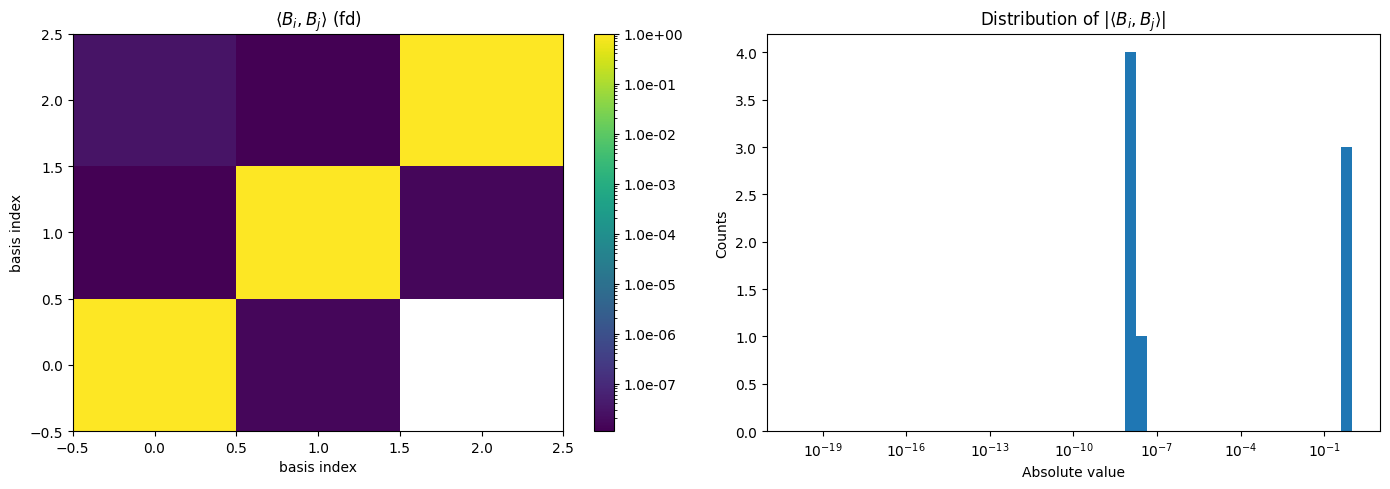

In [16]:
from matplotlib.colors import LogNorm
basis = getattr(rom, f'basis_{VIS_DOMAIN}')
is_complex = rom._is_complex(VIS_DOMAIN)
if is_complex:
    
    gram_matrix = rom._inner(basis, basis, dom=VIS_DOMAIN)
else:
    gram_matrix = basis @ basis.T
arr = gram_matrix.cpu().numpy()
abs_arr = np.abs(arr)
flat = abs_arr.ravel()

print(f"Gram matrix for domain '{VIS_DOMAIN}', shape: {arr.shape}")
print("abs stats -> min: {:.3e}, max: {:.3e}, mean: {:.3e}, std: {:.3e}".format(flat.min(), flat.max(), flat.mean(), flat.std()))
if is_complex:
    print("real part stats -> min: {:.3e}, max: {:.3e}".format(arr.real.min(), arr.real.max()))
    print("imag part stats -> min: {:.3e}, max: {:.3e}".format(arr.imag.min(), arr.imag.max()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1) image of log10(abs(matrix))
vmin = abs_arr[abs_arr > 0].min()
vmax = abs_arr.max()

im = ax[0].imshow(
    abs_arr,
    origin='lower',
    cmap='viridis',
    aspect='auto',
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

ax[0].set_title(r'$\langle B_i, B_j \rangle$' + f' ({VIS_DOMAIN})')
ax[0].set_xlabel('basis index')
ax[0].set_ylabel('basis index')

plt.colorbar(im, ax=ax[0], format=plt.FuncFormatter(lambda x, _: f"{x:.1e}"))
# 2) flattened values: histogram of absolute values
ax[1].hist(flat, bins=np.logspace(np.log10(flat.min()+1e-20), np.log10(flat.max()+1e-5), 50))
ax[1].set_xscale('log')
ax[1].set_xlabel('Absolute value')
ax[1].set_ylabel('Counts')
ax[1].set_title(r'Distribution of $|\langle B_i, B_j \rangle|$')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"rom_gram_matrix_diagnostics_{VIS_DOMAIN}.png"), dpi=300)
plt.show()
plt.close(fig)

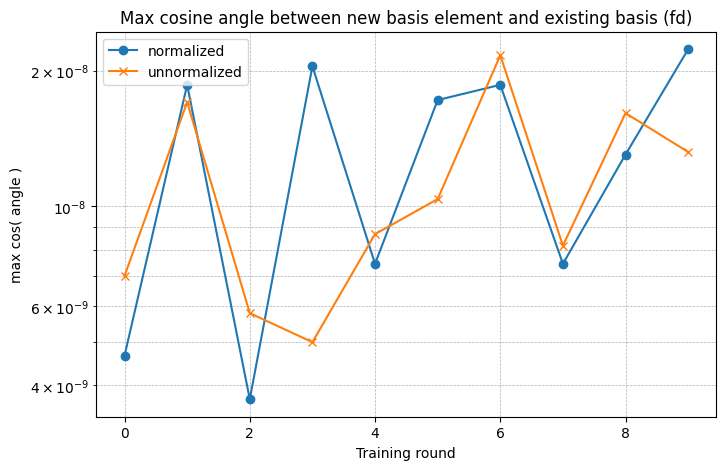

In [17]:
cosine_angles_normalised = gs_diagnose["max_cosine_angle_normalised"]
cosine_angles_unnormalised = gs_diagnose["max_cosine_angle_unnormalised"]

plt.figure(figsize=(8, 5))
plt.plot(cosine_angles_normalised, marker='o', label='normalized')
plt.plot(cosine_angles_unnormalised, marker='x', label='unnormalized')
plt.yscale("log")
plt.xlabel('Training round')
plt.ylabel('max cos( angle )')
plt.legend()
plt.title(f'Max cosine angle between new basis element and existing basis ({VIS_DOMAIN})')
plt.savefig(os.path.join(plot_dir, f"rom_gram_schmidt_cosine_angles_{VIS_DOMAIN}.png"), dpi=300)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

In [18]:
### assessing reconstruction error on training set, as function of number of basis elements used. 
from torch.utils.data import Subset, DataLoader
from pembhb.data import MBHBDataModule
import importlib 
pembhb_data = importlib.import_module("pembhb.data")
importlib.reload(pembhb_data)

<module 'pembhb.data' from '/u/g/gpuleo/pembhb/src/pembhb/data.py'>

In [19]:
datamodule = MBHBDataModule(data_filename, batch_size=400, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="fit")
dataloader = datamodule.train_dataloader(shuffle=False)
freqs = datamodule.get_freqs()
times = datamodule.get_times()
x_axis_dict = {'fd': freqs, 'td': times}
xlabel_dict = {'fd': 'Frequency (Hz)', 'td': 'Time (s)'}
print("loaded datamodule from file")

loaded datamodule from file


In [21]:
wave_key = f'wave_{VIS_DOMAIN}'
noise_key = f'noise_{VIS_DOMAIN}'
n_dim = getattr(rom, f'n_dim_{VIS_DOMAIN}')
is_complex = rom._is_complex(VIS_DOMAIN)

# freq_cutoff_idx: bins below this index are discarded by the ROM (fd only)
cutoff_idx = getattr(rom, 'freq_cutoff_idx', None) or 0

max_rel_err_wave = 0.0
for ii, batch in enumerate(dataloader):
    wave = batch[wave_key]
    noise = batch[noise_key]
    print(f"Batch {ii}: wave shape = {wave.shape}, noise shape = {noise.shape}")
    data = wave + noise

    # Slice to keep only the high-frequency bins that the ROM was trained on
    wave_cutoff = wave[..., cutoff_idx:]
    noise_cutoff = noise[..., cutoff_idx:]
    data_cutoff = data[..., cutoff_idx:]
    params = batch["source_parameters"][:, :2]

    # compress & reconstruct clean waveforms
    coeffs_wave = rom.compress(wave_cutoff, dom=VIS_DOMAIN)
    reconstructed_wave = rom.reconstruct(coeffs_wave, dom=VIS_DOMAIN)

    # compress & reconstruct noisy data
    coeffs_data = rom.compress(data, dom=VIS_DOMAIN)
    reconstructed_data = rom.reconstruct(coeffs_data, dom=VIS_DOMAIN)

    # manual normalise-project-denormalise (replicating ROM internals for verification)
    bsize = wave.shape[0]
    mean_vec = getattr(rom, f'mean_vec_{VIS_DOMAIN}')
    #scale = getattr(rom, f'global_scale_factor_{VIS_DOMAIN}')

    # _IR_wave_out = wave.reshape(bsize, -1).to(rom.device)
    # _IR_norm_wave_in = (_IR_wave_out - mean_vec) / scale
    # _IR_proj_in = rom._project_batch_dom(_IR_norm_wave_in, VIS_DOMAIN)
    # _IR_residual_in = _IR_norm_wave_in - _IR_proj_in

    # _IR_reconstruction_out = _IR_proj_in * scale + mean_vec
    # _IR_residual_out = _IR_wave_out - _IR_reconstruction_out
    # r = (_IR_norm_wave_in - _IR_proj_in) / _IR_norm_wave_in.norm(dim=1, keepdim=True)
    #norms = (r.abs() ** 2).sum(dim=1)

    relative_errors_wave = np.linalg.norm(
        (reconstructed_wave - wave_cutoff).numpy(), axis=(1, 2)
    ) / np.linalg.norm(wave_cutoff.numpy(), axis=(1, 2))
    max_rel_err_wave = max(max_rel_err_wave, np.max(relative_errors_wave))

    relative_errors_data = np.linalg.norm(
        (reconstructed_data - data_cutoff).numpy(), axis=(1, 2)
    ) / np.linalg.norm(data_cutoff.numpy(), axis=(1, 2))

    relative_errors_rec_data_wrt_wave = np.linalg.norm(
        (reconstructed_data - wave_cutoff).numpy(), axis=(1, 2)
    ) / np.linalg.norm(wave_cutoff.numpy(), axis=(1, 2))

    if ii == 4:
        break

print(f"[{VIS_DOMAIN}] max relative error on waveforms in training set: {max_rel_err_wave:.3e}")
print(f"freq_cutoff_idx={cutoff_idx}, n_dim={n_dim}, wave_cutoff.shape={wave_cutoff.shape}")

Batch 0: wave shape = torch.Size([400, 2, 4096]), noise shape = torch.Size([400, 2, 4096])
Batch 1: wave shape = torch.Size([400, 2, 4096]), noise shape = torch.Size([400, 2, 4096])
Batch 2: wave shape = torch.Size([400, 2, 4096]), noise shape = torch.Size([400, 2, 4096])
Batch 3: wave shape = torch.Size([400, 2, 4096]), noise shape = torch.Size([400, 2, 4096])
Batch 4: wave shape = torch.Size([400, 2, 4096]), noise shape = torch.Size([400, 2, 4096])
[fd] max relative error on waveforms in training set: 1.140e-03
freq_cutoff_idx=0, n_dim=4096, wave_cutoff.shape=torch.Size([400, 2, 4096])


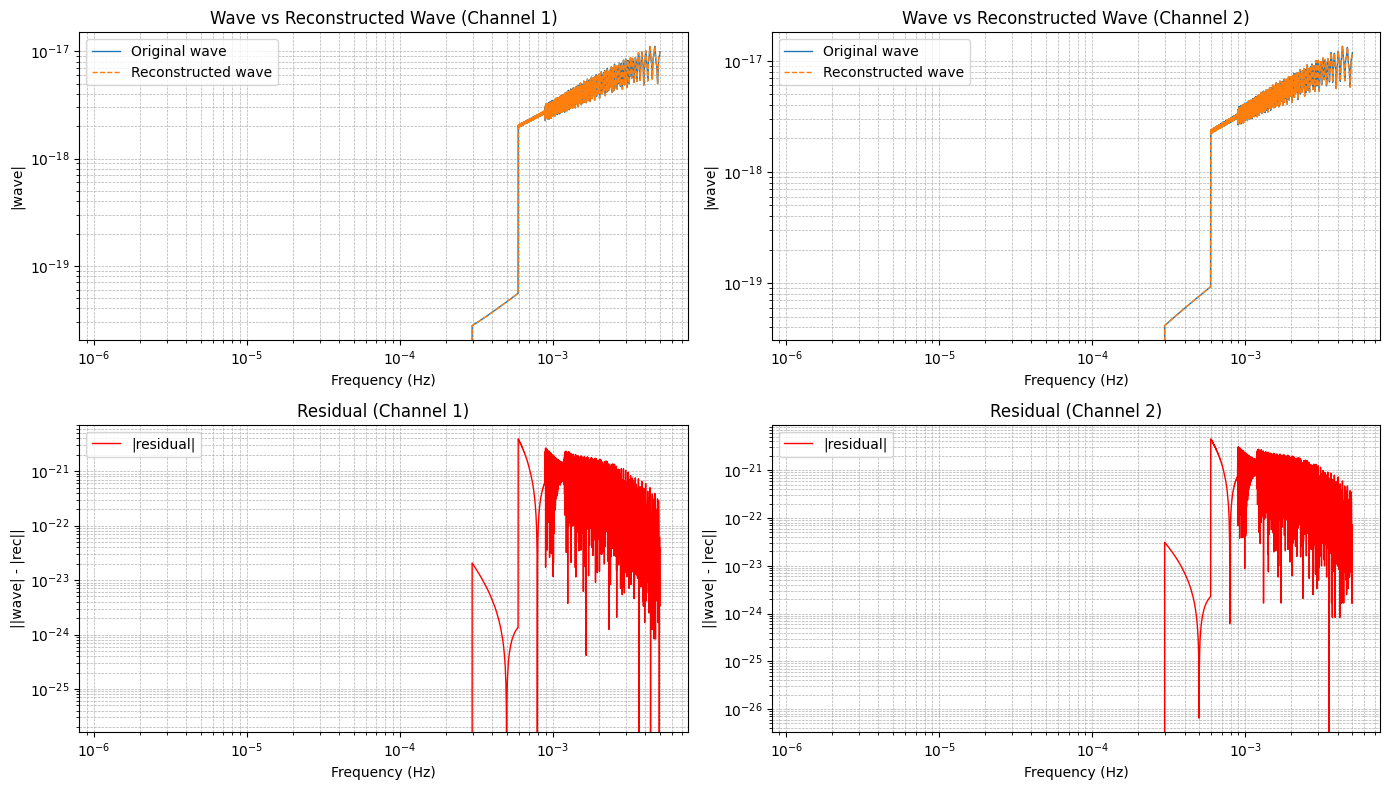

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ch_idx in range(wave_cutoff.shape[1]):
    ax_top = axes[0, ch_idx]
    ax_bot = axes[1, ch_idx]

    wave_abs_ch = wave_cutoff[0, ch_idx, :].abs().cpu().numpy()
    rec_abs_ch = reconstructed_wave[0, ch_idx, :].abs().cpu().numpy()
    residual_abs_ch = np.abs(wave_abs_ch - rec_abs_ch)
    xaxis = x_axis_dict[VIS_DOMAIN][cutoff_idx:]
    ax_top.plot(xaxis, wave_abs_ch, label='Original wave', linewidth=1)
    ax_top.plot(xaxis, rec_abs_ch, label='Reconstructed wave', linestyle='--', linewidth=1)
    ax_top.set_yscale('log')
    ax_top.set_xscale('log')
    ax_top.set_xlabel('Frequency (Hz)')
    ax_top.set_ylabel('|wave|')
    ax_top.set_title(f'Wave vs Reconstructed Wave (Channel {ch_idx + 1})')
    ax_top.legend()
    ax_top.grid(True, which='both', ls='--', lw=0.5)

    ax_bot.plot(xaxis, residual_abs_ch, label='|residual|', color='red', linewidth=1)
    ax_bot.set_yscale('log')
    ax_bot.set_xscale('log')
    ax_bot.set_xlabel('Frequency (Hz)')
    ax_bot.set_ylabel('||wave| - |rec||')
    ax_bot.set_title(f'Residual (Channel {ch_idx + 1})')
    ax_bot.legend()
    ax_bot.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'wave_vs_reconstructed_{VIS_DOMAIN}.png'), dpi=150)
plt.show()

In [23]:
rel_error_example = np.linalg.norm((reconstructed_wave - wave_cutoff).numpy(), axis=(1, 2)) / np.linalg.norm(wave_cutoff.numpy(), axis=(1, 2))

In [33]:
rel_error_example

array([0.01512884, 0.0679414 , 0.02999711, 0.05393809, 0.01703832,
       0.03983147, 0.01333253, 0.01003447, 0.01359585, 0.03113402,
       0.00998385, 0.06328236, 0.02003487, 0.00792257, 0.01066712,
       0.03895863, 0.0115998 , 0.02861227, 0.0770884 , 0.02410838,
       0.02528784, 0.04429827, 0.04437449, 0.02027896, 0.05611007,
       0.03753546, 0.07132491, 0.04045708, 0.00827414, 0.03486859,
       0.04551482, 0.06896886, 0.02485388, 0.03079075, 0.01165431,
       0.03459632, 0.01044489, 0.02830458, 0.01971946, 0.05134322,
       0.06143772, 0.05787532, 0.06291495, 0.04167492, 0.05856773,
       0.01287109, 0.0177395 , 0.01694506, 0.04555782, 0.06657153,
       0.07948259, 0.06464662, 0.04741374, 0.02910833, 0.06018351,
       0.06461575, 0.0296356 , 0.06943835, 0.05198682, 0.07661334,
       0.0681936 , 0.06113118, 0.06919996, 0.07218613, 0.02103472,
       0.03450272, 0.02223401, 0.0342565 , 0.016104  , 0.02528767,
       0.04387271, 0.05761244, 0.0330207 , 0.06279526, 0.05912

In [25]:
# cosine_angles_normalised.shape

In [41]:
relerr_anotherway = np.linalg.norm(_IR_residual_out, axis=1)/ np.linalg.norm(_IR_wave_out, axis=1)
print(torch.max(torch.tensor(relerr_anotherway)))
print(torch.max(_IR_residual_in.abs()))

NameError: name '_IR_residual_out' is not defined

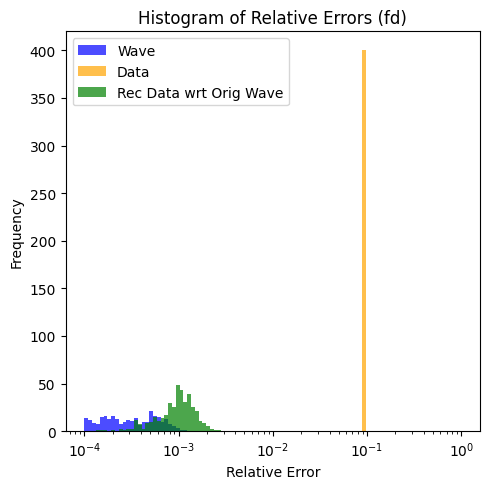

In [27]:
# make a histogram of relative_errors_wave and relative_errors_data
plt.figure(figsize=(5, 5))
bins = np.logspace(-4, 0, 100)
plt.hist(relative_errors_wave, bins=bins, alpha=0.7, label='Wave', color='blue')
plt.hist(relative_errors_data, bins=bins, alpha=0.7, label='Data', color='orange')
plt.hist(relative_errors_rec_data_wrt_wave, bins=bins, alpha=0.7, label='Rec Data wrt Orig Wave', color='green')
mean_relerr_dwrt_wave = np.mean(relative_errors_rec_data_wrt_wave)
plt.xscale('log')
plt.xlabel('Relative Error')
plt.ylabel('Frequency')
plt.title(f'Histogram of Relative Errors ({VIS_DOMAIN})')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"rom_reconstruction_error_histogram_{VIS_DOMAIN}.png"), dpi=300)
plt.show()

In [28]:
wave.shape

torch.Size([400, 2, 4096])

ValueError: x and y must have same first dimension, but have shapes (4096,) and (2048,)

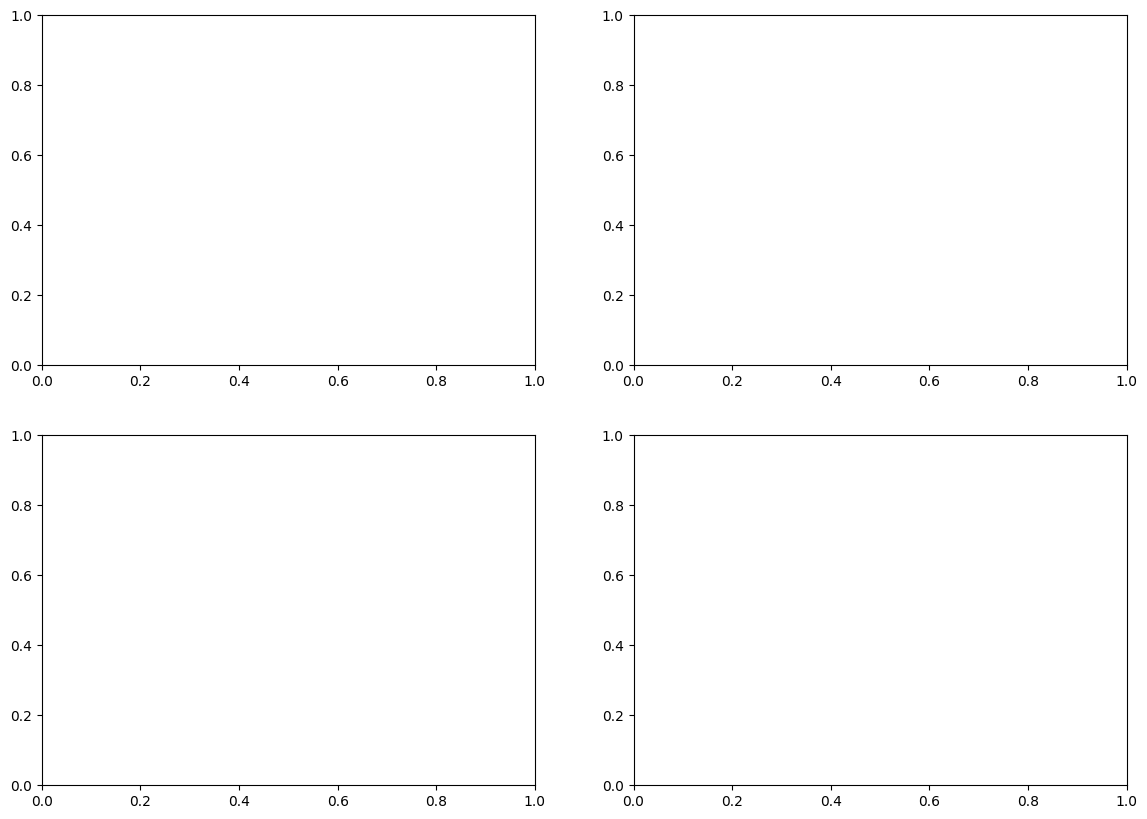

In [27]:
# Plot distribution of errors vs frequency/time bins
# Compute absolute errors
abs_errors_rec = torch.abs(reconstructed_data - wave[...,:n_dim])  # shape (B, ch, n_dim)
abs_errors_wf = torch.abs(reconstructed_wave - wave[...,:n_dim])  # shape (B, ch, n_dim)

wave_abs = torch.abs(wave[...,:n_dim])  # shape (B, ch, n_dim)
# Compute relative errors only where wave is non-zero for ALL batch samples
# For each channel, create a mask where wave is non-zero for all batch items
rel_errors_rec = torch.zeros_like(abs_errors_rec)
rel_errors_wf = torch.zeros_like(abs_errors_wf)
# For each channel, find bins where ALL samples have non-zero wave values
n_channels_vis = getattr(rom, f'n_channels_{VIS_DOMAIN}')
wave_abs = torch.abs(wave[...,:n_dim])  # shape (B, ch, n_dim)

# Create masks for non-zero bins per channel
nonzero_masks = []
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for ch_idx in range(wave.shape[1]):
    ax_data = ax[0, ch_idx]
    ax_wave = ax[1, ch_idx]
    x_axis = x_axis_dict[VIS_DOMAIN]
    x_label = xlabel_dict[VIS_DOMAIN]
    # Mask: True where wave is non-zero for ALL batch samples at this channel
    nonzero_mask = (wave_abs[:, ch_idx, :] != 0).all(dim=0)  # shape (n_dim,)
    
    # Compute relative error only where mask is True
    rel_errors_rec[:, ch_idx, nonzero_mask] = abs_errors_rec[:, ch_idx, nonzero_mask] / wave_abs[:, ch_idx, nonzero_mask]
    rel_errors_wf[:, ch_idx, nonzero_mask] = abs_errors_wf[:, ch_idx, nonzero_mask] / wave_abs[:, ch_idx, nonzero_mask]


    # Check if wave is non-zero for all batch items at this channel
    nonzero_mask = (wave_abs[:, ch_idx, :] != 0).all(dim=0).cpu().numpy()  # shape (n_dim,)
    nonzero_masks.append(nonzero_mask)

# Compute relative errors only where denominator is non-zero
    mean_error = np.mean(rel_errors_rec[:, ch_idx, :].cpu().numpy(), axis=0)
    median_error = np.median(rel_errors_rec[:, ch_idx, :].cpu().numpy(), axis=0)
    p25 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 25, axis=0)
    p75 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 75, axis=0)
    p10 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 10, axis=0)
    p90 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 90, axis=0)
    p05 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 5, axis=0)
    p95 = np.percentile(rel_errors_rec[:, ch_idx, :].cpu().numpy(), 95, axis=0)
    
    # Identify where errors are exactly zero
    zero_mask = (rel_errors_rec[:, ch_idx, :].cpu().numpy() == 0).any(axis=0)
    
    ax_data.plot(x_axis, mean_error, label='Mean', color='red', linewidth=2)
    ax_data.plot(x_axis, median_error, label='Median', color='blue', linewidth=2, linestyle='--')
    ax_data.fill_between(x_axis, p25, p75, alpha=0.3, label='25th-75th pctl', color='blue')
    ax_data.fill_between(x_axis, p10, p90, alpha=0.2, label='10th-90th pctl', color='green')
    ax_data.fill_between(x_axis, p05, p95, alpha=0.1, label='5th-95th pctl', color='orange')
    
    # Mark zero error regions
    if zero_mask.any():
        ax_data.scatter(x_axis[zero_mask], np.ones(zero_mask.sum()) * 1e-15, 
                       color='black', marker='x', s=50, label='Exact zeros', zorder=5)
    
    ax_data.set_xlabel(x_label, fontsize=12)
    ax_data.set_ylabel('|rec_data - wave| / |wave|', fontsize=12)
    if VIS_DOMAIN == 'fd':
        ax_data.set_xscale("log")
    ax_data.set_title(f'Relative Error: Reconstructed Data (Channel {ch_idx + 1}, {VIS_DOMAIN})', fontsize=14)
    ax_data.set_yscale('log')
    ax_data.grid(True, alpha=0.3)
    ax_data.legend(loc='best')
    
    # Plot for waveform reconstruction errors
    ax_wave = ax[1, ch_idx]
    
    channel_errors_wave = rel_errors_wf[:, ch_idx, :].cpu().numpy()
    mean_error_wf = np.mean(channel_errors_wave, axis=0)
    median_error_wf = np.median(channel_errors_wave, axis=0)
    p25_wf = np.percentile(channel_errors_wave, 25, axis=0)
    p75_wf = np.percentile(channel_errors_wave, 75, axis=0)
    p10_wf = np.percentile(channel_errors_wave, 10, axis=0)
    p90_wf = np.percentile(channel_errors_wave, 90, axis=0)
    p05_wf = np.percentile(channel_errors_wave, 5, axis=0)
    p95_wf = np.percentile(channel_errors_wave, 95, axis=0)
    
    # Identify where errors are exactly zero
    zero_mask_wf = (channel_errors_wave == 0).any(axis=0)
    
    ax_wave.plot(x_axis, mean_error_wf, label='Mean', color='red', linewidth=2)
    ax_wave.plot(x_axis, median_error_wf, label='Median', color='blue', linewidth=2, linestyle='--')
    ax_wave.fill_between(x_axis, p25_wf, p75_wf, alpha=0.3, label='25th-75th pctl', color='blue')
    ax_wave.fill_between(x_axis, p10_wf, p90_wf, alpha=0.2, label='10th-90th pctl', color='green')
    ax_wave.fill_between(x_axis, p05_wf, p95_wf, alpha=0.1, label='5th-95th pctl', color='orange')
    
    # Mark zero error regions
    if zero_mask_wf.any():
        ax_wave.scatter(x_axis[zero_mask_wf], np.ones(zero_mask_wf.sum()) * 1e-15, 
                       color='black', marker='x', s=50, label='Exact zeros', zorder=5)
    
    ax_wave.set_xlabel(x_label, fontsize=12)
    ax_wave.set_ylabel('|rec_wave - wave| / |wave|', fontsize=12)
    if VIS_DOMAIN == 'fd':
        ax_wave.set_xscale("log")
    ax_wave.set_title(f'Relative Error: Reconstructed Waveform (Channel {ch_idx + 1}, {VIS_DOMAIN})', fontsize=14)
    ax_wave.set_yscale('log')
    ax_wave.grid(True, alpha=0.3)
    ax_wave.legend(loc='best')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"error_distribution_vs_bins_{VIS_DOMAIN}.png"), dpi=300)
plt.show()

In [72]:
dataset_comparison = "/data/gpuleo/mbhb/20260204_narrowprior_v2/simulation_round_0.h5"
datamodule_comp = MBHBDataModule(dataset_comparison, batch_size=400, num_workers=2, cache_in_memory=False)
datamodule_comp.setup(stage="fit")
dataloader_comp = datamodule_comp.train_dataloader(shuffle=False)

# Import the first batch
batch_comp = next(iter(dataloader_comp))
wave_batch_comp = batch_comp[wave_key]
params_batch_comp = batch_comp["source_parameters"][:, :2]

print(f"Imported wave batch shape: {wave_batch_comp.shape}")


Imported wave batch shape: torch.Size([400, 2, 4096])


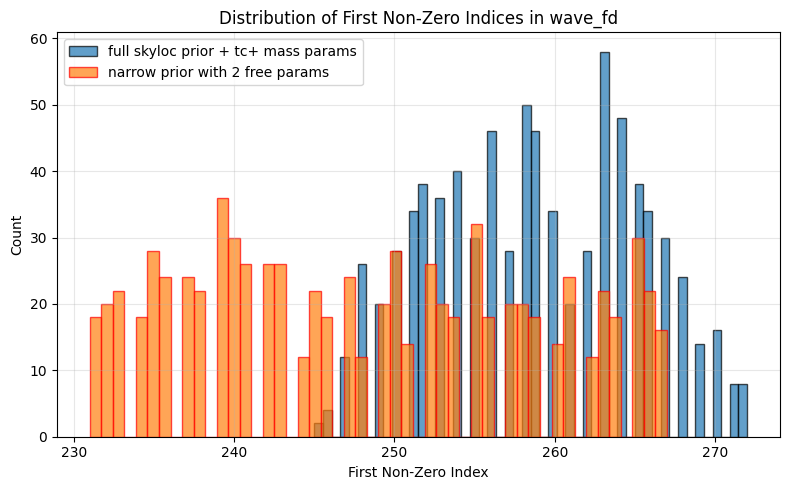

Total signals: 800
Signals with non-zero values: 800
All-zero signals: 0
Min first non-zero index: 245
Max first non-zero index: 272
Mean first non-zero index: 258.74


In [73]:
# Find the smallest non-zero index for each batch and channel in wave_fd
def find_nonzero_indices(wave):
    nonzero_indices = []

    for b in range(wave.shape[0]):
        for ch in range(wave.shape[1]):
            # Find indices where wave is non-zero
            nonzero_mask = wave[b, ch, :] != 0
            if nonzero_mask.any():
                first_nonzero_idx = torch.argmax(nonzero_mask.int()).item()
                nonzero_indices.append(first_nonzero_idx)
            else:
                # If all zeros, append -1 or skip
                nonzero_indices.append(-1)

    nonzero_indices = np.array(nonzero_indices)
    return nonzero_indices

nonzero_indices = find_nonzero_indices(wave)
nonzero_indices_comp = find_nonzero_indices(wave_batch_comp)
# Plot histogram of first non-zero indices
plt.figure(figsize=(8, 5))
# Filter out -1 values (all-zero signals)
valid_indices = nonzero_indices[nonzero_indices >= 0]
valid_indices_comp = nonzero_indices_comp[nonzero_indices_comp >= 0]

plt.hist(valid_indices, bins=50, edgecolor='black', alpha=0.7, label="full skyloc prior + tc+ mass params")
plt.hist(valid_indices_comp, bins=50, edgecolor='red', alpha=0.7, label="narrow prior with 2 free params")
plt.xlabel('First Non-Zero Index')
plt.ylabel('Count')
plt.title(f'Distribution of First Non-Zero Indices in wave_{VIS_DOMAIN}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'first_nonzero_index_distribution_{VIS_DOMAIN}.png'), dpi=150)
plt.show()

print(f"Total signals: {len(nonzero_indices)}")
print(f"Signals with non-zero values: {(nonzero_indices >= 0).sum()}")
print(f"All-zero signals: {(nonzero_indices < 0).sum()}")
print(f"Min first non-zero index: {valid_indices.min()}")
print(f"Max first non-zero index: {valid_indices.max()}")
print(f"Mean first non-zero index: {valid_indices.mean():.2f}")

In [27]:
relative_errors_wave = np.linalg.norm(reconstructed_wave-wave, axis=(1,2))/ np.linalg.norm(wave, axis=(1,2))

norm_numpy = np.linalg.norm(reconstructed_wave - wave, axis=(1,2))
norm_torch = torch.linalg.norm(reconstructed_wave - wave, dim=(1,2))
#implement norm manually. 
def my_norm(tensor, dim, keepdim=False):
    return torch.sqrt(torch.sum(tensor.conj() * tensor, dim=dim, keepdim=keepdim).real)

norm_my = my_norm(reconstructed_wave - wave, dim=(1,2))
zeros_like = torch.zeros(norm_my.shape)
#is any result in the final array different from 0? 
# assert torch.equal(norm_my, torch.zeros(norm_my.shape)), "There are non-zero differences between reconstructed wave and original waveforms!"
# assert torch.equal(norm_torch, zeros_like)
# assert torch.equal(torch.Tensor(norm_numpy), zeros_like)
#assert np.equal(norm_numpy, norm_my.cpu().numpy()), "Custom norm does not match numpy norm!"

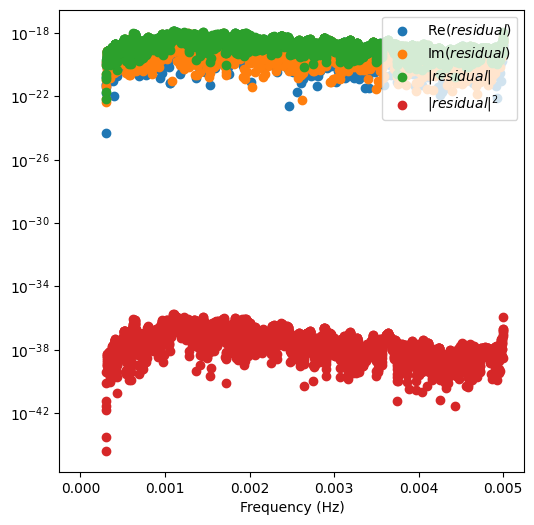

In [28]:
residuals_wave = (reconstructed_wave - wave)[0,0,:]
rre = np.abs(residuals_wave.real.cpu().numpy())
rim = np.abs(residuals_wave.imag.cpu().numpy())
abs2 = rre **2 + rim**2
abs = np.sqrt(abs2)

plt.figure(figsize=(6,6))
plt.scatter(freqs, rre.flatten(), label=r"Re$(residual)$")
plt.scatter(freqs, rim.flatten(), label=r"Im$(residual)$")
plt.scatter(freqs, abs.flatten(), label=r"$|residual|$")
plt.scatter(freqs, abs2.flatten(), label=r"$|residual|^2$")
#plt.ylim(1e-30, 1e-21)

plt.yscale("log")
plt.xlabel("Frequency (Hz)")
# plt.xscale("log")
#plt.ylabel("Counts")
#plt.yscale("log")
plt.legend(loc='upper right')
plt.show()

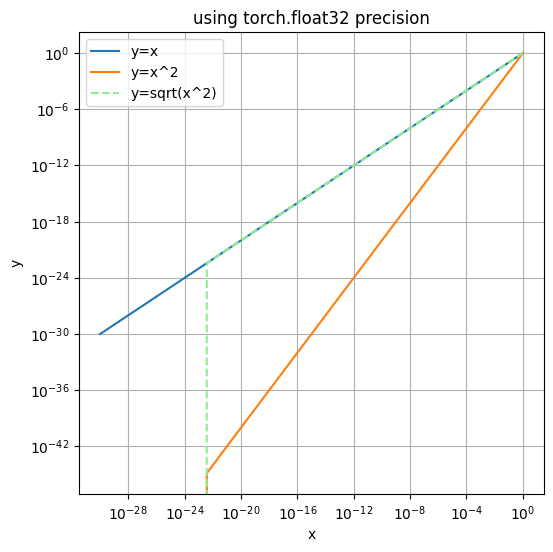

In [29]:
logspaced = torch.logspace(-30, 0, 100) 
plt.figure(figsize=(6,6))
plt.plot(logspaced, logspaced, label="y=x")
plt.plot(logspaced, logspaced**2, label="y=x^2")
plt.plot(logspaced, torch.sqrt(logspaced**2), label="y=sqrt(x^2)", color="lightgreen" , linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("x")
plt.ylabel("y")
plt.title("using torch.float32 precision")
plt.legend()
plt.grid(visible=True)
plt.show()

In [30]:
residuals_wave.shape

plt.figure()
plt.plot(residuals_wave[0,0,:].real.cpu().numpy())

IndexError: too many indices for tensor of dimension 1

<Figure size 640x480 with 0 Axes>

In [ ]:
rre

array([0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 8.735218e-19,
       8.714315e-19, 8.475404e-19], shape=(4096,), dtype=float32)

In [31]:
mean_relerr_datawave = np.mean(relative_errors_rec_data_wrt_wave)

In [32]:
# # Create a 2x3 grid of subplots for amplitude plots
# fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# for i in range(3):  # Iterate over events
#     for channel in range(wave.shape[1]):  # Iterate over channels
#         ax[channel, i].plot(freqs, torch.abs(wave[i, channel]).cpu().numpy(), label=f'Original Waveform (Channel {channel + 1})')
#         ax[channel, i].plot(freqs, torch.abs(reconstructed_wave[i, channel]).cpu().numpy(), label=f'Reconstructed Waveform (Channel {channel + 1})')
#         ax[channel, i].set_title(f'Waveform {i + 1} - Channel {channel + 1}')
#         ax[channel, i].set_xlabel('Frequency (Hz)')
#         ax[channel, i].set_ylabel('Amplitude (Log Scale)')
#         ax[channel, i].set_xscale('log')
#         ax[channel, i].set_yscale('log')
#         ax[channel, i].legend()
#         ax[channel, i].grid(True, which='both', ls='--', lw=0.5)
# plt.tight_layout()

# # Create a 2x3 grid of subplots for phase plots
# fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# for i in range(3):  # Iterate over events
#     for channel in range(wave.shape[1]):  # Iterate over channels
#         ax[channel, i].plot(freqs, torch.angle(wave[i, channel]).cpu().numpy(), label=f'Original Waveform (Channel {channel + 1})')
#         ax[channel, i].plot(freqs, torch.angle(reconstructed_wave[i, channel]).cpu().numpy(), label=f'Reconstructed Waveform (Channel {channel + 1})')
#         ax[channel, i].set_title(f'Waveform {i + 1} - Channel {channel + 1}')
#         ax[channel, i].set_xlabel('Frequency (Hz)')
#         ax[channel, i].set_ylabel('Phase (Radians)')
#         ax[channel, i].set_xscale('log')
#         ax[channel, i].set_yscale('linear')
#         ax[channel, i].legend()
#         ax[channel, i].grid(True, which='both', ls='--', lw=0.5)
# plt.tight_layout()

plt.show()



In [33]:
####### study distance in different representation spaces. 
# Flatten the last two dimensions to compute distances
reconstructed_wave_flat = reconstructed_wave.view(reconstructed_wave.shape[0], -1)
wave_flat = wave.view(wave.shape[0], -1)


# Compute the Euclidean distance matrix for reconstructed_wave
diff_reconstructed = reconstructed_wave_flat.unsqueeze(1) - reconstructed_wave_flat.unsqueeze(0)
dist_matrix_reconstructed = torch.sqrt(torch.sum(diff_reconstructed.conj() * diff_reconstructed, dim=-1).real)

# Compute the Euclidean distance matrix for wave
diff_wave = wave_flat.unsqueeze(1) - wave_flat.unsqueeze(0)
dist_matrix_wave = torch.sqrt(torch.sum(diff_wave.conj() * diff_wave, dim=-1).real)

# Compute the Euclidean dist mat for coeffs_wave
diff_coeffs = coeffs_wave.unsqueeze(1) - coeffs_wave.unsqueeze(0)
dist_matrix_coeffs = torch.sqrt(torch.sum(diff_coeffs.conj() * diff_coeffs, dim=-1).real)

# Euclidean distance matrices for data : 
reconstructed_data_flat = reconstructed_data.view(reconstructed_data.shape[0], -1)
data_flat = data.view(data.shape[0], -1)

# Euclidean distance matrix for parameters 
dist_matrix_params = torch.sqrt(torch.sum(( params.unsqueeze(1) - params.unsqueeze(0))**2, dim=-1))



diff_reconstructed_data = reconstructed_data_flat.unsqueeze(1) - reconstructed_data_flat.unsqueeze(0)
dist_matrix_reconstructed_data = torch.sqrt(torch.sum(diff_reconstructed_data.conj() * diff_reconstructed_data, dim=-1).real)
diff_data = data_flat.unsqueeze(1) - data_flat.unsqueeze(0)
dist_matrix_data = torch.sqrt(torch.sum(diff_data.conj() * diff_data, dim=-1).real)
diff_coeffs_data = coeffs_data.unsqueeze(1) - coeffs_data.unsqueeze(0)
dist_matrix_coeffs_data = torch.sqrt(torch.sum(diff_coeffs_data.conj() * diff_coeffs_data, dim=-1).real)

# Extract the upper triangular part of the distance matrices
upper_tri_reconstructed = torch.triu(dist_matrix_reconstructed, diagonal=1)
upper_tri_wave = torch.triu(dist_matrix_wave, diagonal=1)
upper_tri_coeffs = torch.triu(dist_matrix_coeffs, diagonal=1)
upper_tri_reconstructed_data = torch.triu(dist_matrix_reconstructed_data, diagonal=1)
upper_tri_data = torch.triu(dist_matrix_data, diagonal=1)
upper_tri_coeffs_data = torch.triu(dist_matrix_coeffs_data, diagonal=1)
upper_tri_params = torch.triu(dist_matrix_params, diagonal=1)


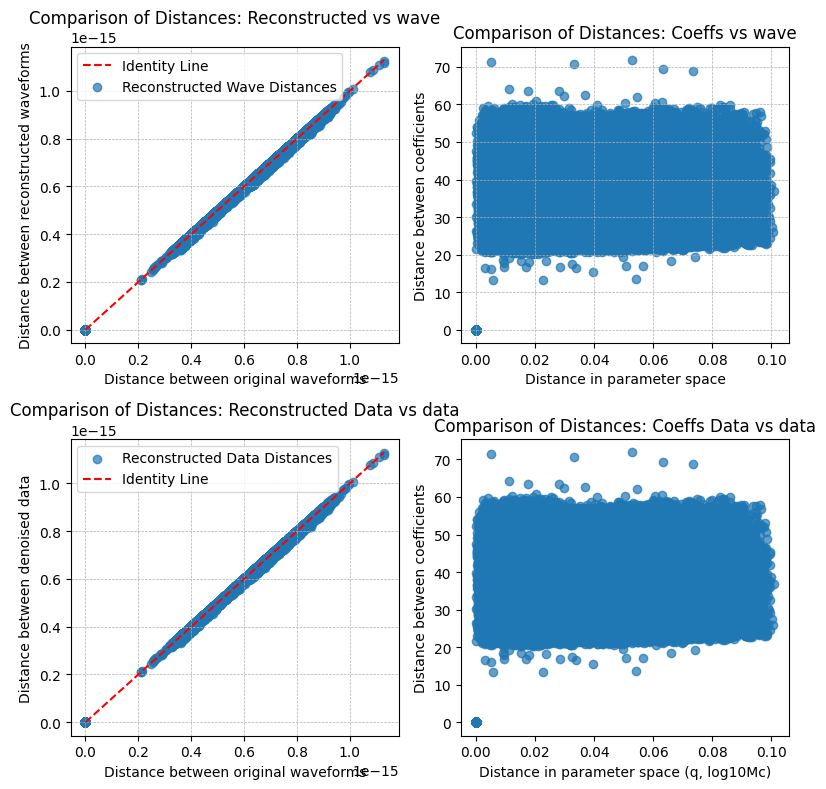

In [63]:
# Plot the upper triangular distances for reconstructed_wave and wave
plt.figure(figsize=(8, 8))
# plot the identity line
plt.subplot(2, 2, 1)
plt.plot([0, upper_tri_wave.max().item()], [0, upper_tri_wave.max().item()], 'r--', label='Identity Line')
plt.scatter(upper_tri_wave.cpu().numpy(), upper_tri_reconstructed.cpu().numpy(), label='Reconstructed Wave Distances', alpha=0.7)
plt.xlabel('Distance between original waveforms')
plt.ylabel('Distance between reconstructed waveforms')
plt.title('Comparison of Distances: Reconstructed vs wave')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)
plt.subplot(2, 2, 2)
plt.scatter(upper_tri_params.cpu().numpy(), upper_tri_coeffs.cpu().numpy(), label='Coefficients Distances', alpha=0.7)
plt.xlabel('Distance in parameter space')
plt.ylabel('Distance between coefficients')
plt.title('Comparison of Distances: Coeffs vs wave')
plt.grid(True, which='both', ls='--', lw=0.5)

plt.subplot(2, 2, 3) 
plt.scatter(upper_tri_wave.cpu().numpy(), upper_tri_reconstructed_data.cpu().numpy(), label='Reconstructed Data Distances', alpha=0.7)
plt.plot([0, upper_tri_wave.max().item()], [0, upper_tri_wave.max().item()], 'r--', label='Identity Line')
plt.xlabel('Distance between original waveforms')
plt.ylabel('Distance between denoised data')
plt.title('Comparison of Distances: Reconstructed Data vs data')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

plt.subplot(2,2,4)
plt.scatter(upper_tri_params.cpu().numpy(), upper_tri_coeffs_data.cpu().numpy(), label='Coefficients Data Distances', alpha=0.7)
plt.xlabel('Distance in parameter space (q, log10Mc)')
plt.ylabel('Distance between coefficients')
plt.title('Comparison of Distances: Coeffs Data vs data')

plt.tight_layout()

plt.savefig(os.path.join(plot_dir, "rom_distance_matrices_comparison.png"), dpi=300)
plt.show()
plt.close()


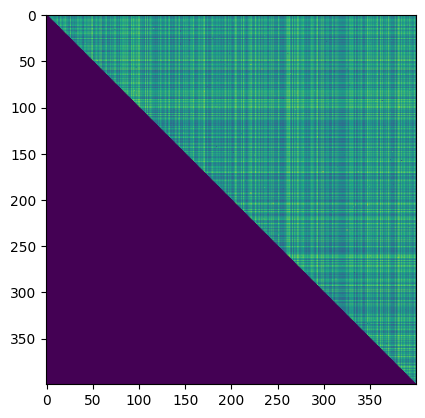

In [35]:
plt.imshow(upper_tri_data.cpu().numpy())

In [36]:
# ii, jj = torch.where(upper_tri_data == 0 )
# for i, j in zip(ii, jj): 
#     if i != j:
#         print(i, j)

In [37]:
# intrinsic dimension computation given distance matrix
def intrinsic_dimension(distance_matrix):
    N = distance_matrix.shape[0]
    distances_sorted = np.sort(distance_matrix, axis=1)
    mu = distances_sorted[:,2]/distances_sorted[:,1]
    mu = np.sort(mu)
    intrinsic_dim = N/(np.sum(np.log(mu)))
    return intrinsic_dim

In [38]:
id_original = intrinsic_dimension(dist_matrix_wave)
id_reconstructed = intrinsic_dimension(dist_matrix_reconstructed)
id_coeffs = intrinsic_dimension(dist_matrix_coeffs)
id_reconstructed_data = intrinsic_dimension(dist_matrix_reconstructed_data)
id_data = intrinsic_dimension(dist_matrix_data)
id_coeffs_data = intrinsic_dimension(dist_matrix_coeffs_data)
id_params = intrinsic_dimension(dist_matrix_params)


In [39]:
# print all of them : 
print(f"Intrinsic Dimension - Original Waveforms: {id_original:.3f}")
print(f"Intrinsic Dimension - Reconstructed Waveforms: {id_reconstructed:.3f}")
print(f"Intrinsic Dimension - Coefficients: {id_coeffs:.3f}")
print(f"Intrinsic Dimension - Reconstructed Data: {id_reconstructed_data:.3f}")
print(f"Intrinsic Dimension - Data with noise: {id_data:.3f}")
print(f"Intrinsic Dimension - Coefficients Data: {id_coeffs_data:.3f}")
print(f"Intrinsic Dimension - Parameters (q, log10Mc): {id_params:.3f}")

Intrinsic Dimension - Original Waveforms: 14.531
Intrinsic Dimension - Reconstructed Waveforms: 14.610
Intrinsic Dimension - Coefficients: 14.610
Intrinsic Dimension - Reconstructed Data: 14.695
Intrinsic Dimension - Data with noise: 15.162
Intrinsic Dimension - Coefficients Data: 14.695
Intrinsic Dimension - Parameters (q, log10Mc): 2.082


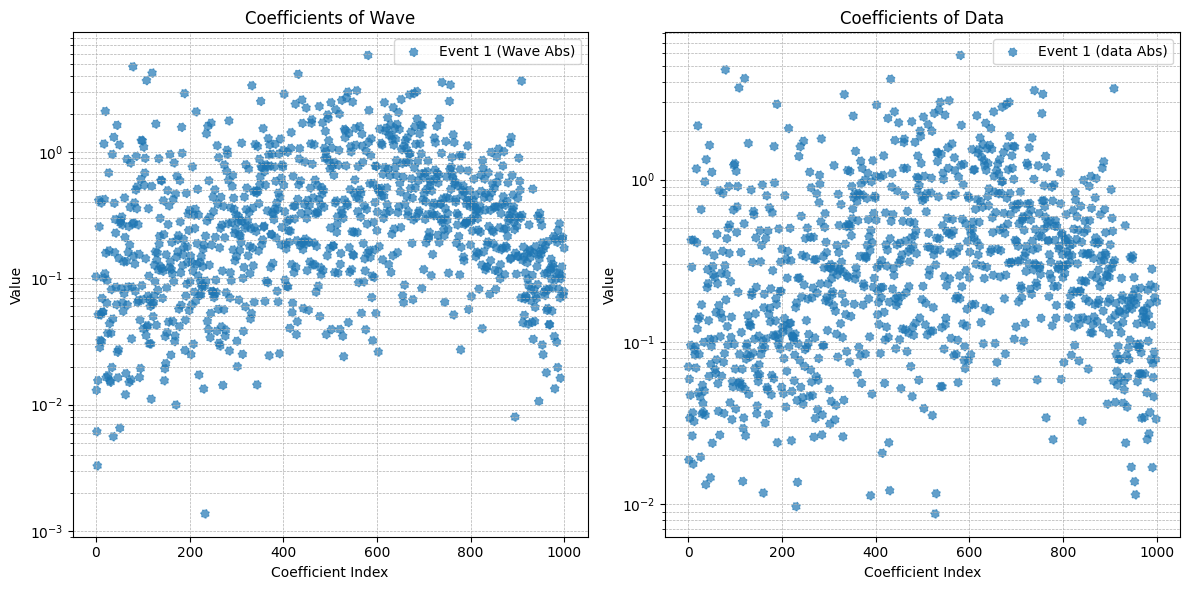

In [66]:
#  plot coeffs wave and coeffs data as function of their index 
plt.figure(figsize=(12, 6))

# Plot coeffs_wave as a function of their index
plt.subplot(1, 2, 1)
N_events = 1
for i in range(N_events):  # Iterate over events
    # plt.plot(range(coeffs_wave.shape[1]), coeffs_wave[i, :].real.cpu().numpy(), label=f'Event {i+1} (Real)', alpha=0.7)
    # plt.plot(range(coeffs_wave.shape[1]), coeffs_wave[i, :].imag.cpu().numpy(), linestyle='--', label=f'Event {i+1} (Imag)', alpha=0.7)
    plt.scatter(range(coeffs_wave.shape[1]), coeffs_wave[i, :].abs().cpu().numpy(), linestyle=':', label=f'Event {i+1} (Wave Abs)', alpha=0.7)
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.yscale('log')
plt.title('Coefficients of Wave')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

# Plot coeffs_data as a function of their index
plt.subplot(1, 2, 2)
for i in range(N_events):  # Iterate over events
    # plt.plot(range(coeffs_data.shape[1]), coeffs_data[i, :].real.cpu().numpy(), label=f'Event {i+1} (Real)', alpha=0.7)
    # plt.plot(range(coeffs_data.shape[1]), coeffs_data[i, :].imag.cpu().numpy(), linestyle='--', label=f'Event {i+1} (Imag)', alpha=0.7)
    plt.scatter(range(coeffs_data.shape[1]), coeffs_data[i, :].abs().cpu().numpy(), linestyle=':', label=f'Event {i+1} (data Abs)', alpha=0.7)
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.yscale('log')
plt.title('Coefficients of Data')
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "rom_coefficients_vs_index.png"), dpi=300)
plt.show()

In [ ]:
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Plot for channel A (i=0)
# ax[0].plot(freqs, residual_wave[0, 0, :].numpy(), label='Channel A', color='blue')
# ax[0].plot(freqs, residual_wrong[ 0, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[0].set_title('Residual Wave - Channel A')
# ax[0].set_xlabel('Frequency (Hz)')
# ax[0].set_ylabel('Residual Amplitude')
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
# ax[0].grid(True, which='both', ls='--', lw=0.5)
# ax[0].legend()

# # Plot for channel E (i=1)
# ax[1].plot(freqs, residual_wave[0, 1, :].numpy(), label='Channel E', color='green')
# ax[1].plot(freqs, residual_wrong[1, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[1].set_title('Residual Wave - Channel E')
# ax[1].set_xlabel('Frequency (Hz)')
# ax[1].set_ylabel('Residual Amplitude')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
# ax[1].grid(True, which='both', ls='--', lw=0.5)
# ax[1].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
plt.plot()

In [ ]:
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Plot for channel A (i=0)
# ax[0].plot(freqs, residual_relative_wave[0, 0, :].numpy(), label='Channel A', color='blue')
# ax[0].plot(freqs, residual_relative_wrong[0, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[0].set_title('Relative Residual Wave - Channel A')
# ax[0].set_xlabel('Frequency (Hz)')
# ax[0].set_ylabel('Relative Residual Amplitude')
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
# ax[0].grid(True, which='both', ls='--', lw=0.5)
# ax[0].legend()

# # Plot for channel E (i=1)
# ax[1].plot(freqs, residual_relative_wave[0, 1, :].numpy(), label='Channel E', color='green')
# ax[1].plot(freqs, residual_relative_wrong[1, :].numpy(), label='Residual wrt wrong waveform', color='red', linestyle='--')
# ax[1].set_title('Relative Residual Wave - Channel E')
# ax[1].set_xlabel('Frequency (Hz)')
# ax[1].set_ylabel('Relative Residual Amplitude')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
# ax[1].grid(True, which='both', ls='--', lw=0.5)
# ax[1].legend()

# plt.tight_layout()
# plt.show()


mean of channel 0, event 0: 2.456e-21+1.880e-21j
 std: 5.879e-18
mean of channel 1, event 0: 1.599e-21-3.116e-21j
 std: 7.039e-18


mean of channel 0, event 1: -1.584e-21+3.285e-21j
 std: 5.482e-18
mean of channel 1, event 1: 4.025e-21+1.083e-21j
 std: 6.582e-18
mean of channel 0, event 2: -3.163e-21+3.143e-21j
 std: 5.940e-18
mean of channel 1, event 2: 4.082e-21+2.962e-21j
 std: 7.102e-18
mean of channel 0, event 3: -2.085e-21-3.774e-21j
 std: 5.897e-18
mean of channel 1, event 3: -3.925e-21+3.134e-21j
 std: 7.052e-18


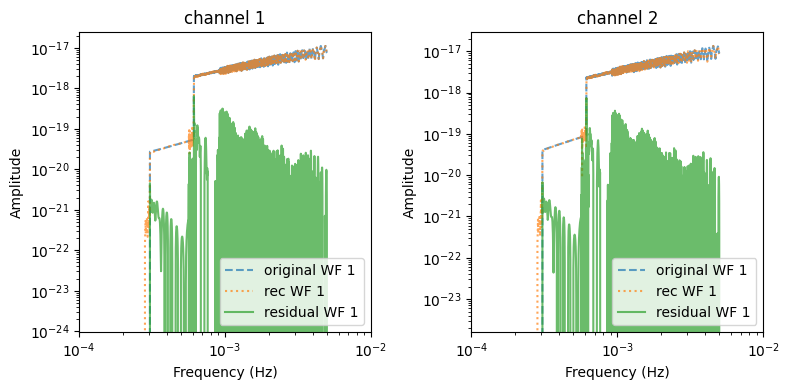

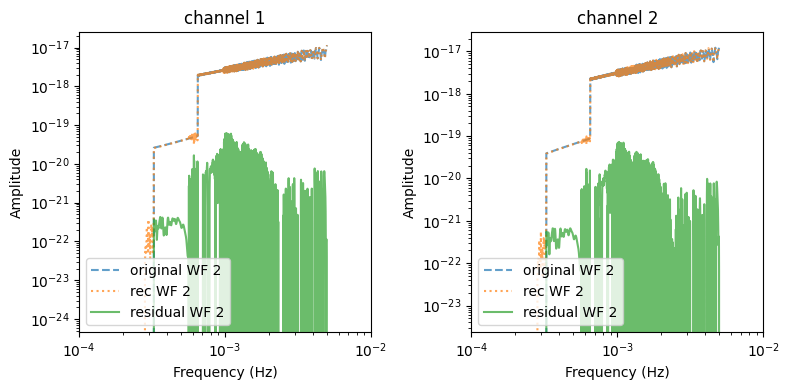

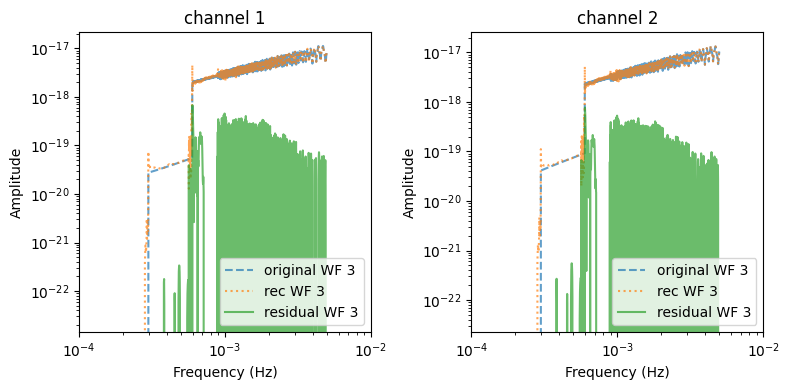

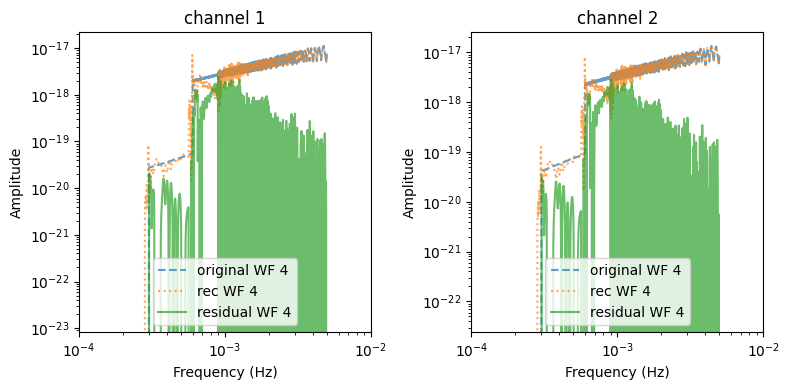

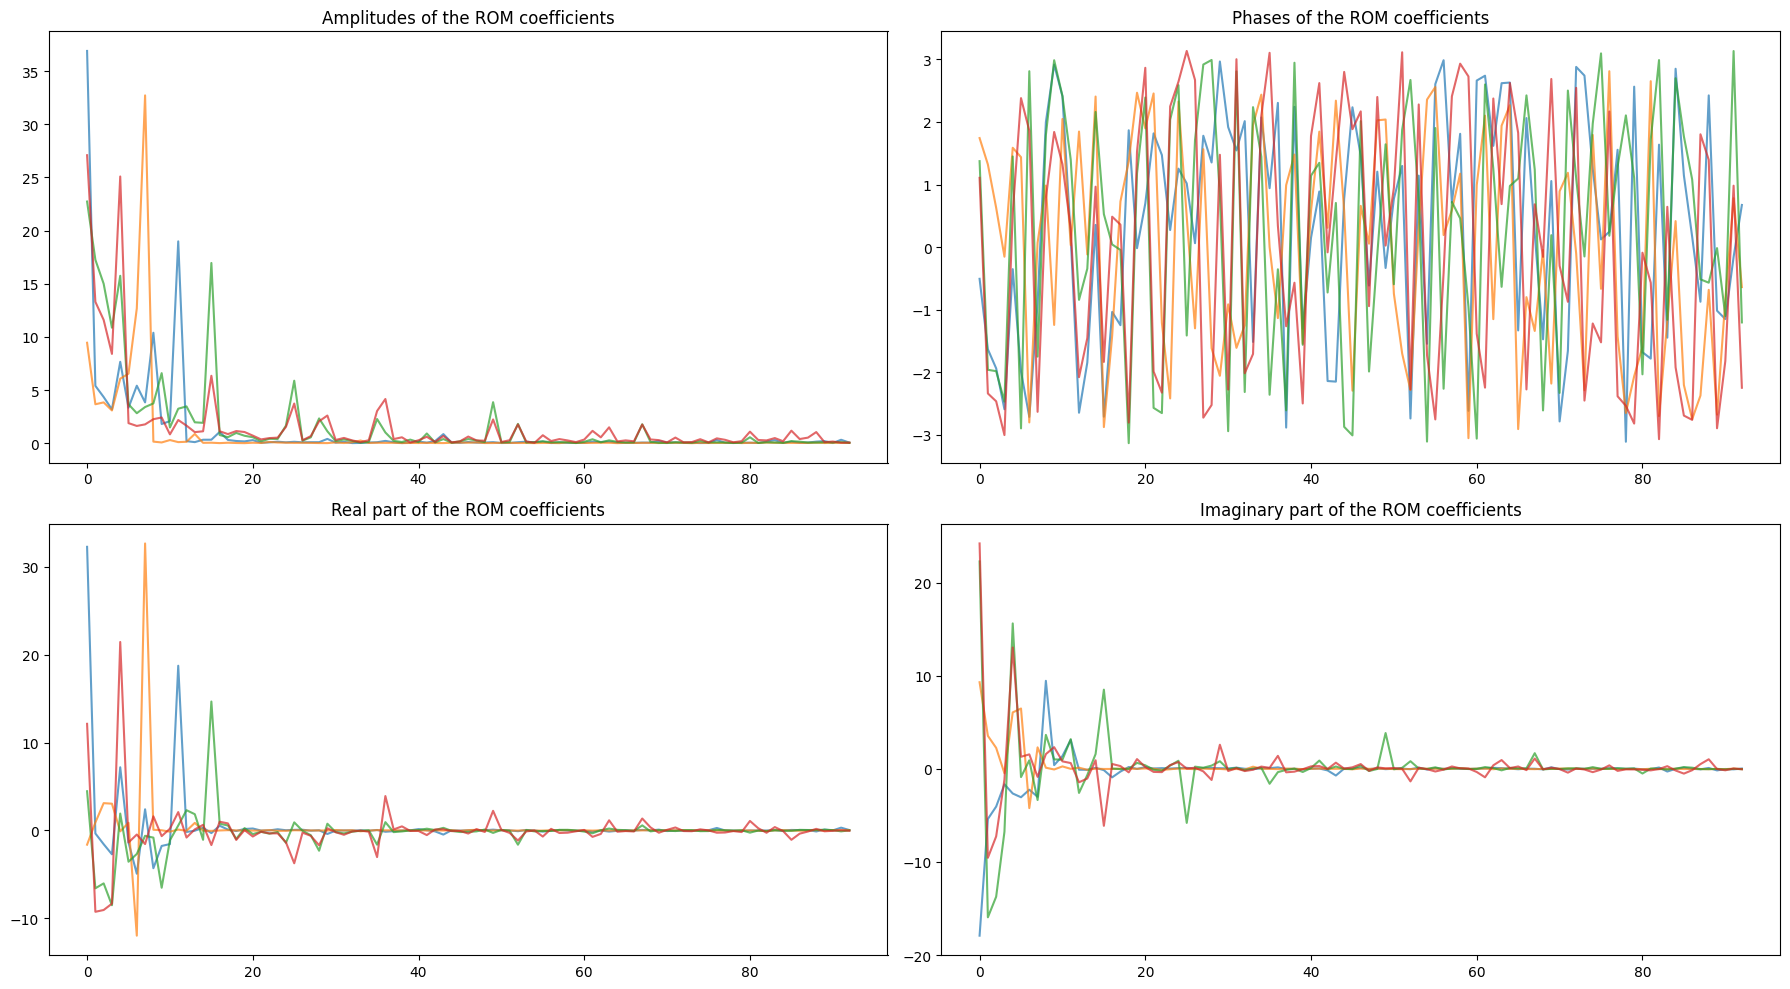

In [ ]:
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1,n_channels, figsize=(8, 4))   
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave[j,i,:]).item():.3e}\n std: {torch.std(wave[j,i,:]).item():.3e}")
        #ax[0].plot(freqs, data[j,i,:].numpy(), label=f'original data {j+1}', alpha=0.7) 
        ax[i].plot(freqs, amplitudes_wave[j,i,:].numpy(), '--', label=f'original WF {j+1}', alpha=0.7)
        #ax[1].plot(freqs, reconstructed_logamplitudes_data[j,i,:].numpy(), '--', label=f'rec data {j+1}', alpha=0.7)
        ax[i].plot(freqs, reconstructed_amplitudes[j,i,:].numpy(), ':', label=f'rec WF {j+1}', alpha=0.7)
        ax[i].plot(freqs, amplitudes_wave[j,i,:].numpy()-reconstructed_amplitudes[j,i,:].numpy(), '-', label=f'residual WF {j+1}', alpha=0.7)
        ax[i].set_title(f'channel {i+1}')
        ax[i].set_ylabel('Amplitude')
        ax[i].set_xscale("log")
        ax[i].legend()
        ax[i].set_yscale("log")
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    
    fig.savefig(os.path.join(plot_dir, f"rom_amplitudes_event_{j+1}.png"), dpi=150)
    plt.tight_layout()

# plot the abs , phase, re and im of the coeffs for N_events_plot events: 
fig, ax = plt.subplots(2, 2, figsize=(18, 10))
for j in range(N_events_plot):
    ax[0, 0].plot(torch.abs(coeffs_data[j,:]).cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[0, 1].plot(torch.angle(coeffs_data[j,:]).cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[1, 0].plot(coeffs_data[j,:].real.cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
    ax[1, 1].plot(coeffs_data[j,:].imag.cpu().numpy(), label=f'ev {j+1}', alpha=0.7)
ax[0, 0].set_title('Amplitudes of the ROM coefficients')
ax[0, 1].set_title('Phases of the ROM coefficients')
ax[1, 0].set_title('Real part of the ROM coefficients')
ax[1, 1].set_title('Imaginary part of the ROM coefficients')
plt.tight_layout()

#### plot reconstructed vs original data for a few examples 


mean of channel 0, event 0: -4.692e-21-1.634e-21j
 std: 5.990e-18
mean of channel 1, event 0: -1.035e-21+5.635e-21j
 std: 7.157e-18
mean of channel 0, event 1: -4.704e-21-1.593e-21j
 std: 5.990e-18
mean of channel 1, event 1: -9.864e-22+5.641e-21j
 std: 7.157e-18
mean of channel 0, event 2: -4.390e-21-2.378e-21j
 std: 5.991e-18
mean of channel 1, event 2: -1.937e-21+5.436e-21j
 std: 7.158e-18
mean of channel 0, event 3: -4.393e-21-2.373e-21j
 std: 5.991e-18
mean of channel 1, event 3: -1.931e-21+5.438e-21j
 std: 7.158e-18


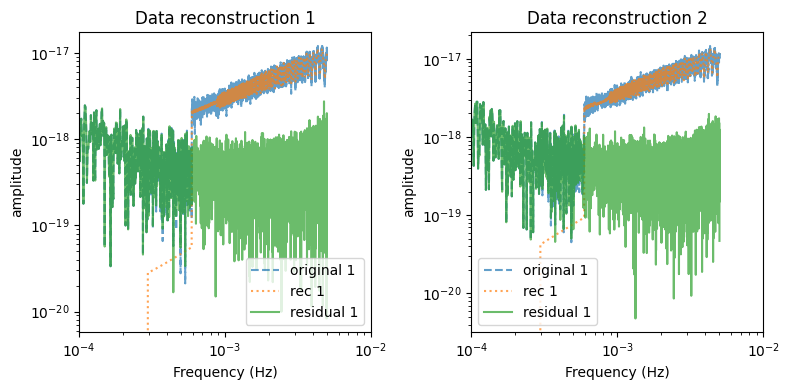

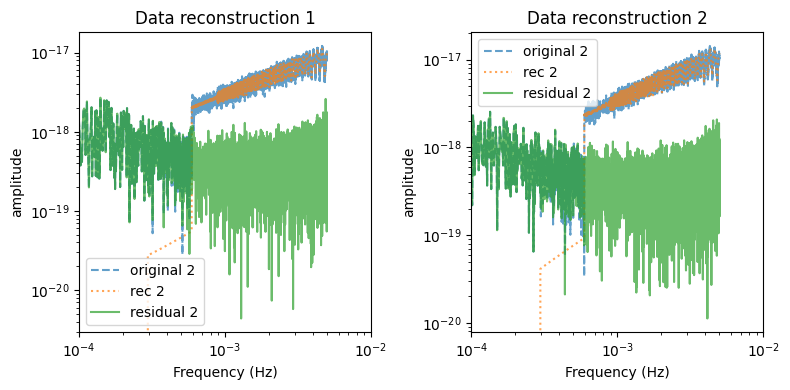

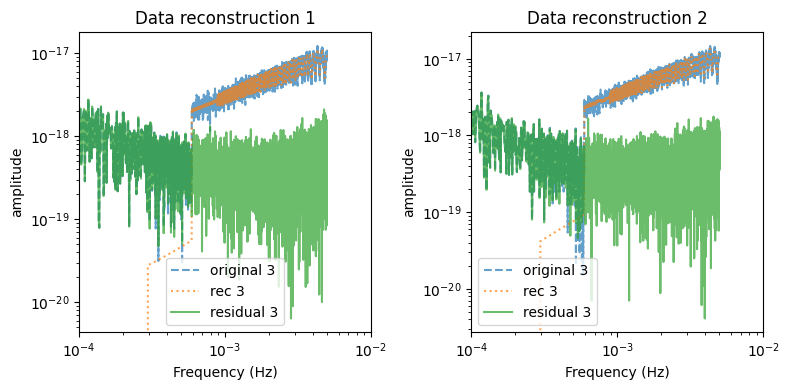

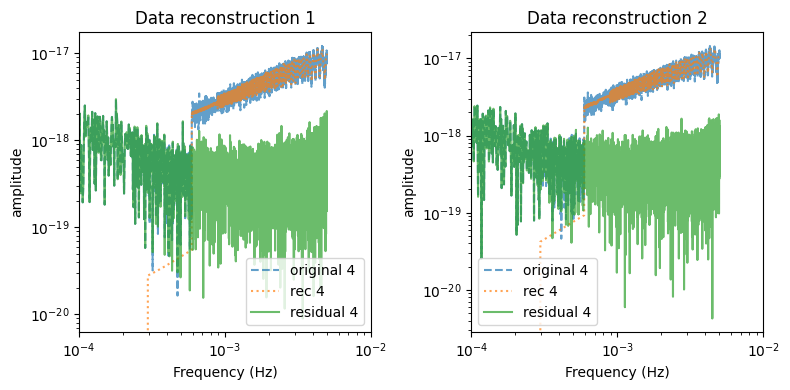

In [ ]:
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1,n_channels, figsize=(8, 4))   
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave[j,i,:]).item():.3e}\n std: {torch.std(wave[j,i,:]).item():.3e}")
        #ax[0].plot(freqs, data[j,i,:].numpy(), label=f'original data {j+1}', alpha=0.7) 
        ax[i].plot(freqs, amplitudes_data[j,i,:].numpy(), '--', label=f'original {j+1}', alpha=0.7)
        #ax[1].plot(freqs, reconstructed_logamplitudes_data[j,i,:].numpy(), '--', label=f'rec data {j+1}', alpha=0.7)
        ax[i].plot(freqs, reconstructed_amplitudes_data[j,i,:].numpy(), ':', label=f'rec {j+1}', alpha=0.7)
        ax[i].plot(freqs, (data[j,i,:]-reconstructed_data[j,i,:]).abs().cpu().numpy(), '-', label=f'residual {j+1}', alpha=0.7)
        ax[i].set_title(f'Data reconstruction {i+1}')
        ax[i].set_ylabel('amplitude')
        ax[i].set_xscale("log")
        ax[i].legend()
        ax[i].set_yscale("log")
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    
    fig.savefig(os.path.join(plot_dir, f"rom_amplitudes_event_{j+1}.png"), dpi=150)
    plt.tight_layout()

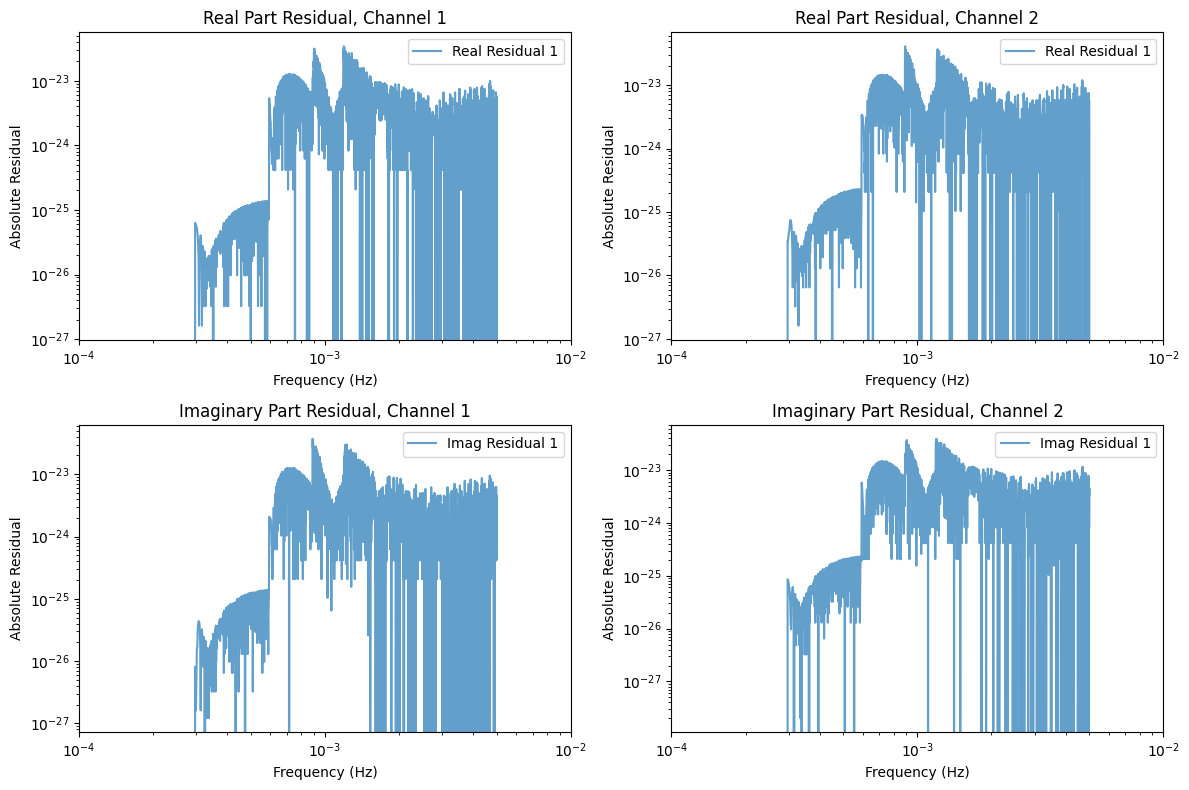

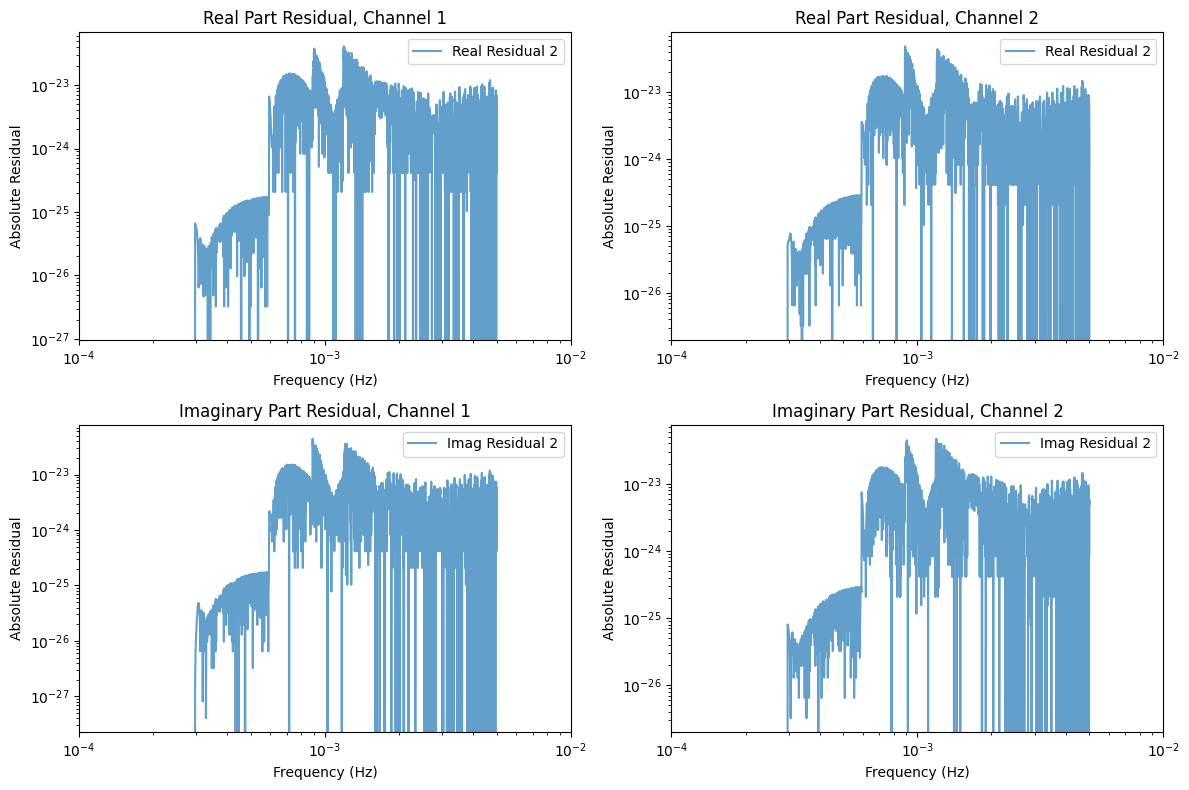

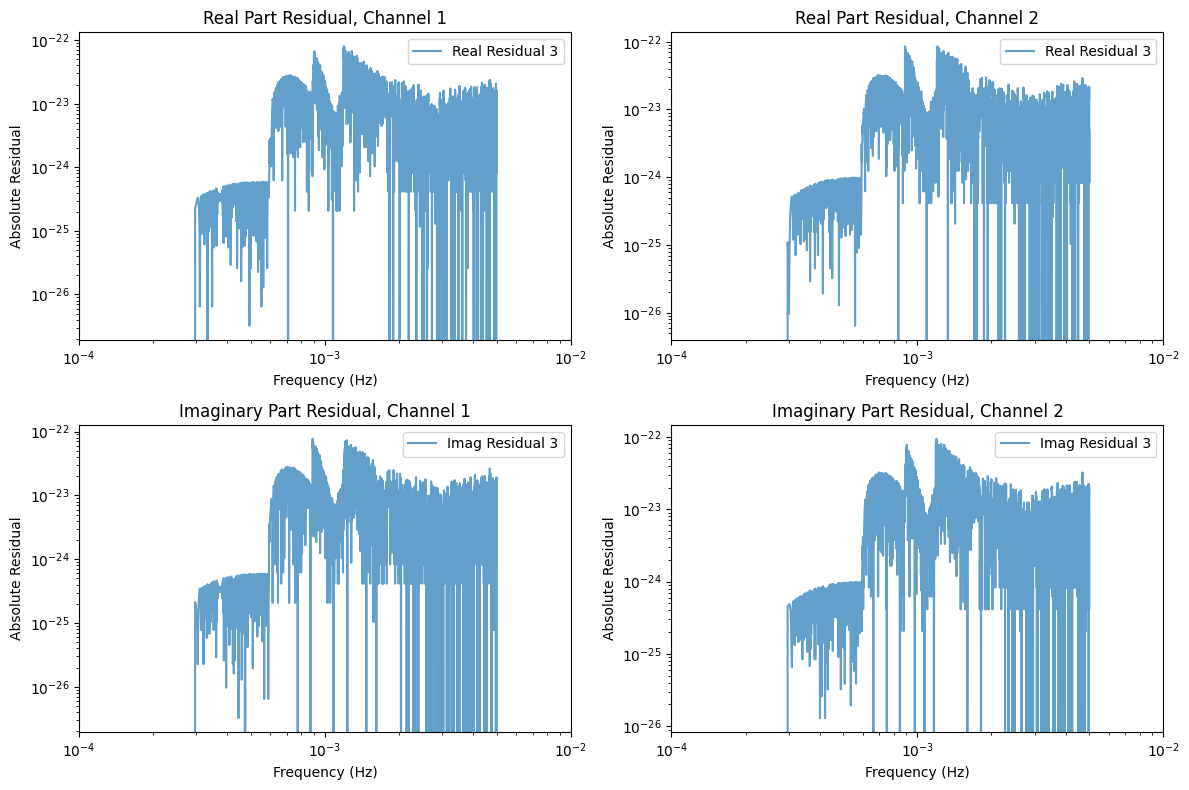

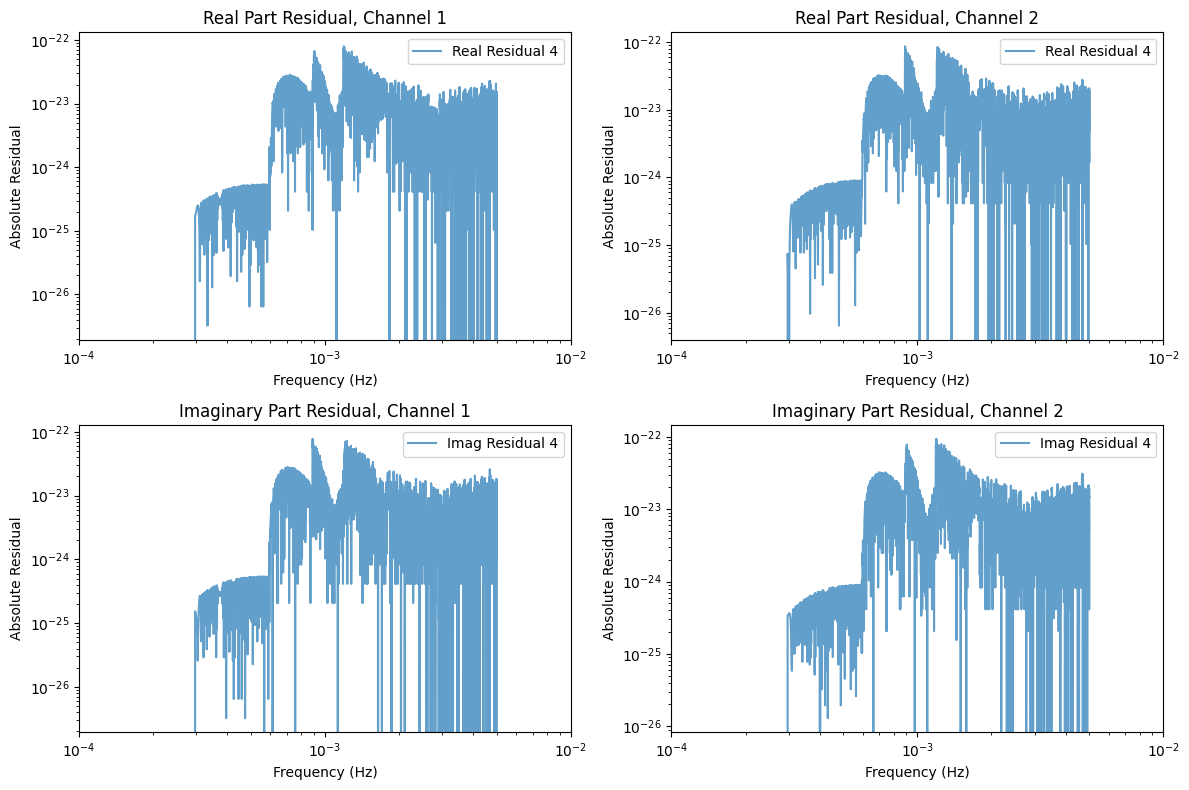

In [ ]:
# Plot absolute residuals for real and imaginary parts of the waveform
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(2, n_channels, figsize=(12, 8))
    for i in range(n_channels):
        # Real part residual
        ax[0, i].plot(freqs, (wave[j, i, :].real - reconstructed_wave[j, i, :].real).abs().numpy(), '-', label=f'Real Residual {j+1}', alpha=0.7)
        ax[0, i].set_title(f'Real Part Residual, Channel {i+1}')
        ax[0, i].set_ylabel('Absolute Residual')
        ax[0, i].set_xscale("log")
        ax[0, i].set_yscale("log")
        ax[0, i].legend()
        ax[0, i].set_xlabel('Frequency (Hz)')
        ax[0, i].set_xlim(1e-4, 1e-2)

        # Imaginary part residual
        ax[1, i].plot(freqs, (wave[j, i, :].imag - reconstructed_wave[j, i, :].imag).abs().numpy(), '-', label=f'Imag Residual {j+1}', alpha=0.7)
        ax[1, i].set_title(f'Imaginary Part Residual, Channel {i+1}')
        ax[1, i].set_ylabel('Absolute Residual')
        ax[1, i].set_xscale("log")
        ax[1, i].set_yscale("log")
        ax[1, i].legend()
        ax[1, i].set_xlabel('Frequency (Hz)')
        ax[1, i].set_xlim(1e-4, 1e-2)

    plt.tight_layout()
    plt.show()

mean of channel 0, event 0: -4.692e-21-1.634e-21j
 std: 5.990e-18
mean of channel 1, event 0: -1.035e-21+5.635e-21j
 std: 7.157e-18
mean of channel 0, event 1: -4.704e-21-1.593e-21j
 std: 5.990e-18
mean of channel 1, event 1: -9.864e-22+5.641e-21j
 std: 7.157e-18
mean of channel 0, event 2: -4.390e-21-2.378e-21j
 std: 5.991e-18
mean of channel 1, event 2: -1.937e-21+5.436e-21j
 std: 7.158e-18
mean of channel 0, event 3: -4.393e-21-2.373e-21j
 std: 5.991e-18
mean of channel 1, event 3: -1.931e-21+5.438e-21j
 std: 7.158e-18


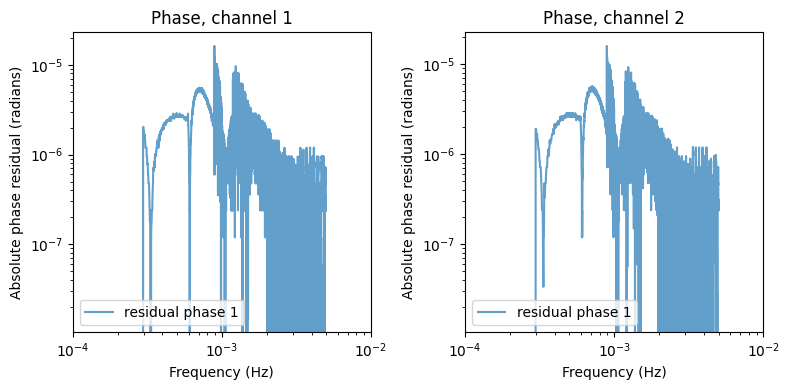

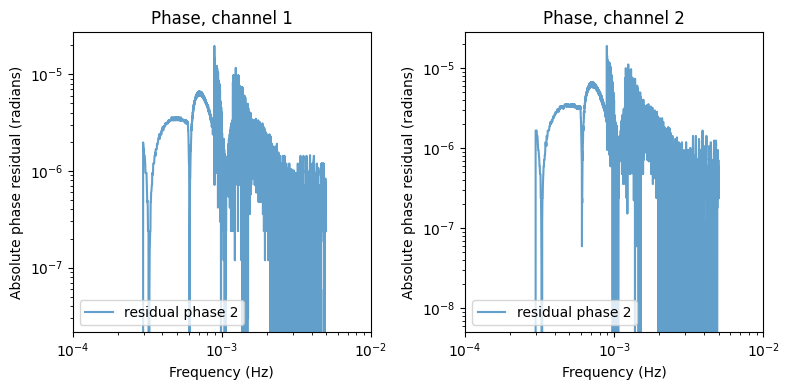

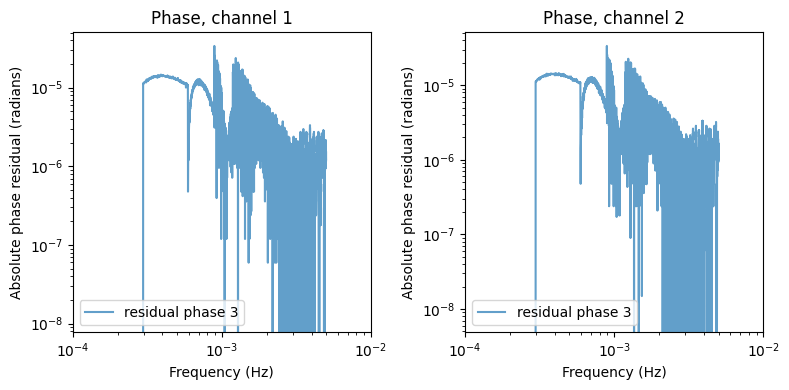

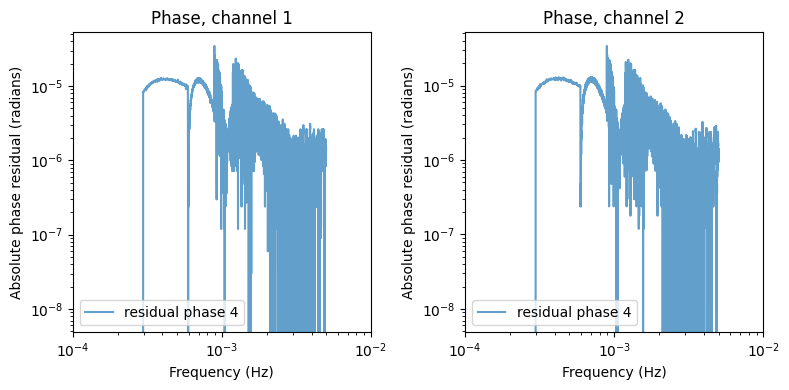

In [ ]:
# plot difference in phases between original and reconstructed waveforms : 
n_channels = rom.n_channels
N_events_plot = 4
for j in range(N_events_plot):
    fig, ax = plt.subplots(1, n_channels, figsize=(8, 4))
    for i in range(n_channels):
        print(f"mean of channel {i}, event {j}: {torch.mean(wave[j, i, :]).item():.3e}\n std: {torch.std(wave[j, i, :]).item():.3e}")
        # ax[i].plot(freqs, phases_wave[j, i, :].numpy(), '--', label=f'original WF {j+1}', alpha=0.7)
        # ax[i].plot(freqs, reconstructed_phases_wave[j, i, :].numpy(), ':', label=f'rec WF {j+1}', alpha=0.7)
        ax[i].plot(freqs, (phases_wave[j, i, :] - reconstructed_phases_wave[j, i, :]).abs().numpy(), '-', label=f'residual phase {j+1}', alpha=0.7)
        ax[i].set_title(f'Phase, channel {i+1}')
        ax[i].set_ylabel('Absolute phase residual (radians)')
        ax[i].set_xscale("log")
        ax[i].set_yscale("log")
        ax[i].legend()
        ax[i].set_xlabel('Frequency (Hz)')
        ax[i].set_xlim(1e-4, 1e-2)

    plt.tight_layout()

#### plot variation in signal with varying parameters...

In [ ]:
from torch.utils.data import Subset, DataLoader
from pembhb.data import MBHBDataModule
# importlib.reload(pembhb_data)
import importlib 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
fix_q_filename = "/data/gpuleo/mbhb/fix_q_vary_mc_2x.h5"
datamodule = MBHBDataModule(fix_q_filename, batch_size=100, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="test")
dataloader = datamodule.test_dataloader()

for idx, batch in enumerate(dataloader): 
    data_fixq = batch["wave"]+batch["noise_fd"]  # shape (B, 2*ch, n_freq),  has amplitude and phase
    wave_fixq = batch["wave"]  # shape (B, ch, n_freq), contains complex numbers 
    params_fixq =  batch["source_parameters"][:,:2]  # shape (B, 2)

print(data_fixq.shape)

torch.Size([100, 2, 4096])


In [ ]:
fix_mc_filename = "/data/gpuleo/mbhb/fix_mc_vary_q_2x.h5"
datamodule = MBHBDataModule(fix_mc_filename, batch_size=100, num_workers=2, cache_in_memory=False)
datamodule.setup(stage="test")
dataloader = datamodule.test_dataloader()

for idx, batch in enumerate(dataloader): 
    data_fixmc = batch["wave"]+batch["noise_fd"]  # shape (B, 2*ch, n_freq),  has amplitude and phase
    wave_fixmc = batch["wave"]  # shape (B, ch, n_freq), contains complex numbers 
    params_fixmc = batch["source_parameters"][:,:2]  # shape (B, 2)

print(data_fixmc.shape)

torch.Size([100, 2, 4096])


In [115]:
print(torch.set_printoptions(precision=8))
print(params_fixq)

None
tensor([[5.26646042, 4.68375015],
        [5.26629686, 4.68375015],
        [5.26631689, 4.68375015],
        [5.26625967, 4.68375015],
        [5.26643372, 4.68375015],
        [5.26622248, 4.68375015],
        [5.26634026, 4.68375015],
        [5.26623344, 4.68375015],
        [5.26639462, 4.68375015],
        [5.26644230, 4.68375015],
        [5.26634645, 4.68375015],
        [5.26640320, 4.68375015],
        [5.26645184, 4.68375015],
        [5.26640606, 4.68375015],
        [5.26644897, 4.68375015],
        [5.26624966, 4.68375015],
        [5.26629829, 4.68375015],
        [5.26625681, 4.68375015],
        [5.26632547, 4.68375015],
        [5.26635027, 4.68375015],
        [5.26631212, 4.68375015],
        [5.26639032, 4.68375015],
        [5.26636600, 4.68375015],
        [5.26623631, 4.68375015],
        [5.26638412, 4.68375015],
        [5.26640892, 4.68375015],
        [5.26649666, 4.68375015],
        [5.26620293, 4.68375015],
        [5.26632595, 4.68375015],
        [

In [177]:
# take the middle point for the chirp mass: 
middle_mc = 5.26635
idx_middle = (torch.argmin(torch.abs(params_fixq[:,0]- middle_mc)))
print(idx_middle, params_fixq[idx_middle,:])


tensor(19) tensor([5.26635027, 4.68375015])


In [ ]:
reference_wave = wave_fixq[idx_middle:idx_middle+1,:,:]
reldist_ref_fix_q = np.linalg.norm( wave_fixq - reference_wave, axis=(1,2))/ np.linalg.norm(reference_wave, axis=(1,2))
reldist_ref_fix_mc = np.linalg.norm( wave_fixmc - reference_wave, axis=(1,2))/ np.linalg.norm(reference_wave, axis=(1,2))

In [ ]:

print(reference_wave.shape, wave_fixq.shape)

torch.Size([1, 2, 4096]) torch.Size([100, 2, 4096])


In [180]:
sort_fixq_by_mc = torch.argsort(params_fixq[:,0])
sort_fixmc_by_q = torch.argsort(params_fixmc[:,1])

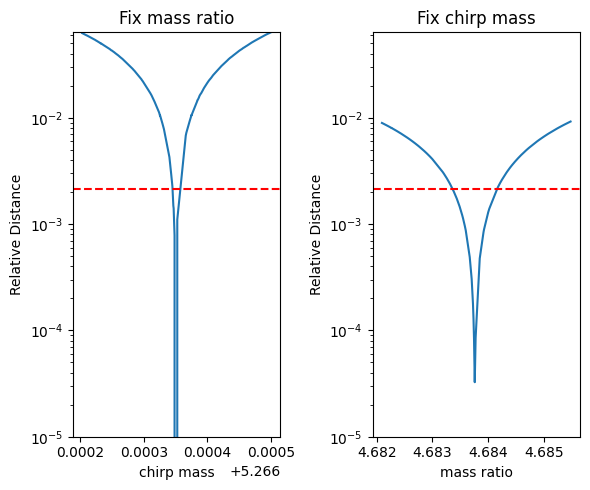

In [181]:
shared_ylim = (1e-5, max(reldist_ref_fix_q.max(), reldist_ref_fix_mc.max()))
plt.figure(figsize=(6,5))
plt.subplot(1,2,1)
plt.plot(params_fixq[sort_fixq_by_mc,0], reldist_ref_fix_q[sort_fixq_by_mc])
plt.xlabel("chirp mass")
plt.title("Fix mass ratio")
plt.ylabel("Relative Distance")
plt.axhline(mean_relerr_dwrt_wave, color='r', linestyle='--')
plt.yscale("log")
plt.ylim(shared_ylim)
plt.subplot(1,2,2)
plt.plot(params_fixmc[sort_fixmc_by_q,1], reldist_ref_fix_mc[sort_fixmc_by_q])
plt.axhline(mean_relerr_dwrt_wave, color='r', linestyle='--')
plt.title("Fix chirp mass")
plt.xlabel("mass ratio")
plt.ylabel("Relative Distance")
plt.yscale("log")
plt.ylim(shared_ylim)
plt.tight_layout()

plt.show()

In [157]:
print(shared_ylim)

(1e-05, np.float32(0.06360279))


### chi square test to convince Rob

In [112]:
# import the power spectral density used to generate the data
import h5py 
with h5py.File(data_filename, 'r') as f:
    asd = f['asd'][:]
    psd = asd**2
    freqs = f["frequencies"][:]

### apply the same filter that was used to generate the noise in the data
filtered_freqs_indices = np.argwhere((freqs > 5e-5)).reshape(-1)
psd_torch = torch.Tensor(psd)
df = freqs[1]-freqs[0]

In [ ]:
residual_data = reconstructed_data - data 
numerator = (  residual_data.conj() * residual_data )
variance = psd_torch / (4*df) 
print(variance.shape)

# retain only the frequencies that have been low passed
num_filtered = numerator[:,:,filtered_freqs_indices]
variance_filtered = variance[:,filtered_freqs_indices]
# filtered_numerator = numerator
normalised_residual = ( num_filtered ) / variance_filtered
chi_square = torch.sum( normalised_residual, dim=(1,2))
Ndof = filtered_freqs_indices.shape[0]*rom.n_channels*2  # factor 2 for re and im parts
print(f"n dof: {Ndof}, len filtered freqs: {len(filtered_freqs_indices)}")

torch.Size([2, 4096])
n dof: 16224, len filtered freqs: 4056


/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:896: ComplexWarning: Casting complex values to real discards the imaginary part
  db = np.array(np.diff(bin_edges), float)
/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


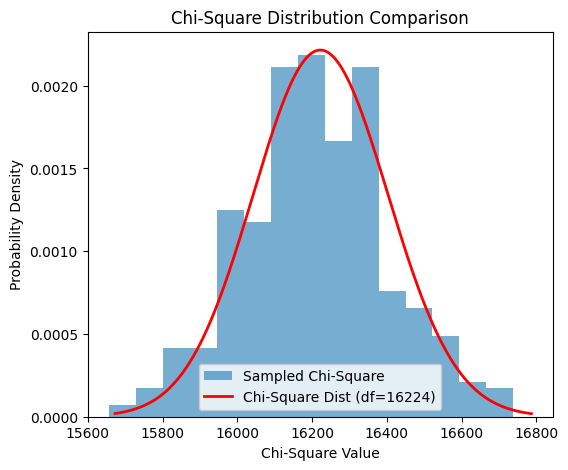

In [208]:
#compare the distribution of chi_square samples with the chi square distribution with Ndof degrees of freedom
from scipy.stats import chi2
chi2_dist = chi2(df=Ndof)
x = np.linspace(chi2_dist.ppf(0.001), chi2_dist.ppf(0.999), 1000)
plt.figure(figsize=(6,5))
plt.hist(chi_square.cpu().numpy(), bins=15, density=True, alpha=0.6, label='Sampled Chi-Square')
plt.plot(x, chi2_dist.pdf(x), 'r-', lw=2, label=f'Chi-Square Dist (df={Ndof})')
plt.xlabel('Chi-Square Value')
plt.ylabel('Probability Density')
plt.title('Chi-Square Distribution Comparison')
plt.legend()
plt.show()

(array([ 3., 10., 14., 14., 12., 13., 19.,  6.,  6.,  3.]),
 array([0.0920404 , 0.0924638 , 0.0928872 , 0.09331061, 0.09373401,
        0.09415741, 0.09458081, 0.09500422, 0.09542762, 0.09585103,
        0.09627443]),
 <BarContainer object of 10 artists>)

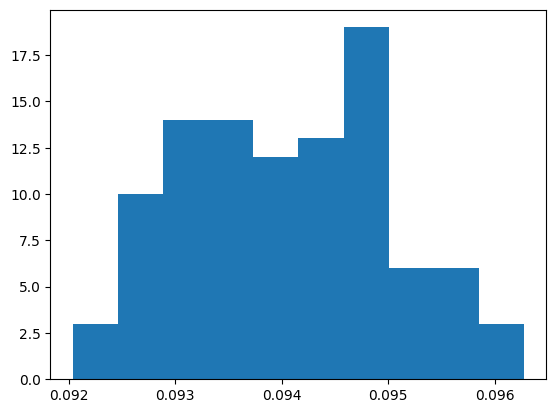

In [137]:
####
plt.hist(relative_errors_data)

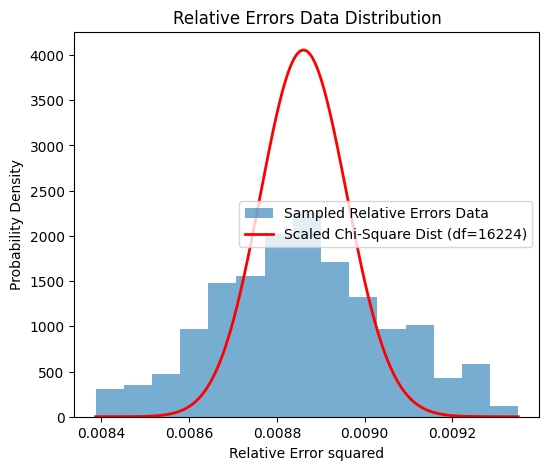

In [ ]:
mean_psd = torch.mean(psd_torch[:, filtered_freqs_indices])
sigma_bar2 = mean_psd / (4*df)
mean_data_square_norm = torch.mean( torch.linalg.norm(data[:,:,filtered_freqs_indices], dim=(1,2))**2, dim=0 )
## relative_errors_data is roughly distributed as a random variable x = mean_psd / mean_data_square_norm * chi2(df=Ndof)
scaling_factor = sigma_bar2 / mean_data_square_norm
# plot the histogram of relative_errors_data and overlay the scaled chi2 distribution
plt.figure(figsize=(6,5))
plt.hist(relative_errors_data**2, bins=15, density=True, alpha=0.6, label='Sampled Relative Errors Data')
x = np.linspace(np.min(relative_errors_data**2), np.max(relative_errors_data**2), 1000)

# should_be_chi2 = relative_errors_data**2 / scaling_factor 
# plt.figure(figsize=(6,5))
# plt.hist(should_be_chi2, bins=15, density=True, alpha=0.6, label='Scaled Relative Errors Data')
plt.plot(x, chi2_dist.pdf(x / scaling_factor)/scaling_factor, 'r-', lw=2, label=f'Scaled Chi-Square Dist (df={Ndof})')
plt.xlabel('Relative Error squared')
plt.ylabel('Probability Density')
plt.title('Relative Errors Data Distribution')
plt.legend()
plt.show()